<a href="https://colab.research.google.com/github/Adhul-R/AI-Hackathon/blob/main/himalayan_earthquake_final_logisticreg_77accuarcay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install required libraries

In [26]:
!pip -q install xgboost lightgbm catboost imbalanced-learn shap tensorflow openpyxl

Import libraries and configure the experiment

In [27]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    log_loss
)

from sklearn.preprocessing import label_binarize

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["axes.grid"] = True

DATA_PATH = "/content/himalayan_seismicity_20000.csv"

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [28]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving himalayan_seismicity_20000.csv to himalayan_seismicity_20000 (1).csv
Uploaded files:
himalayan_seismicity_20000 (1).csv


In [29]:
import shutil
import os

uploaded_filename = list(uploaded.keys())[0]

if uploaded_filename != "himalayan_seismicity_20000.csv":
    shutil.copy(
        uploaded_filename,
        "/content/himalayan_seismicity_20000.csv"
    )

print("Dataset path:", DATA_PATH)

Dataset path: /content/himalayan_seismicity_20000.csv


Data collection and initial inspection

In [30]:
df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five observations:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe().T)

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTarget Distribution:")
display(df["earthquake_risk"].value_counts().sort_index())

Dataset Shape: (20000, 20)

Columns:
['latitude', 'longitude', 'b_value', 'seismicity_rate', 'inter_event_time', 'coulomb_stress', 'magnitude', 'depth_km', 'pga', 'gps_deformation_mm', 'groundwater_change', 'energy_release', 'azimuthal_gap', 'snr', 'ps_time_diff', 'distance_to_fault', 'b_anomaly', 'seismic_ratio', 'stress_index', 'earthquake_risk']

First five observations:


,latitude,longitude,b_value,seismicity_rate,inter_event_time,coulomb_stress,magnitude,depth_km,pga,gps_deformation_mm,groundwater_change,energy_release,azimuthal_gap,snr,ps_time_diff,distance_to_fault,b_anomaly,seismic_ratio,stress_index,earthquake_risk
0,34.126539,80.139784,0.809629,7.297748,3.077596,0.009208,3.949926,20.114325,0.021179,15.962660,-2.673211,2.000000e+09,32.232321,5.102585,6.823077,10.672446,-0.090161,2.039847,1.416208,2
1,30.608224,75.960494,1.037621,5.206055,11.992935,0.014158,3.431016,23.620141,0.010000,11.004957,5.781190,3.975564e+08,34.426257,7.732649,8.309407,9.411474,0.142756,0.416720,1.461139,2
2,35.015278,75.630636,0.908109,2.516581,9.961363,0.007775,3.967271,35.019360,0.014116,4.310601,-0.990557,2.000000e+09,104.028144,4.242356,1.358154,4.107769,0.017876,0.240560,1.083213,0
3,33.322364,73.228916,0.745099,4.030640,11.204353,0.007937,3.975857,31.949444,0.017777,6.828072,5.418525,2.000000e+09,28.143776,3.128825,7.393025,7.008372,-0.128067,0.344371,1.316012,1
4,26.988862,96.969731,0.921027,12.000000,3.619741,0.008216,3.785649,11.285441,0.028929,4.476127,-7.631385,1.293082e+09,48.495720,4.573635,2.721880,8.040909,0.039397,2.912805,1.547245,2



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   latitude            20000 non-null  float64
 1   longitude           20000 non-null  float64
 2   b_value             20000 non-null  float64
 3   seismicity_rate     20000 non-null  float64
 4   inter_event_time    20000 non-null  float64
 5   coulomb_stress      20000 non-null  float64
 6   magnitude           20000 non-null  float64
 7   depth_km            20000 non-null  float64
 8   pga                 20000 non-null  float64
 9   gps_deformation_mm  20000 non-null  float64
 10  groundwater_change  20000 non-null  float64
 11  energy_release      20000 non-null  float64
 12  azimuthal_gap       20000 non-null  float64
 13  snr                 20000 non-null  float64
 14  ps_time_diff        20000 non-null  float64
 15  distance_to_fault   20000 non-n

,count,mean,std,min,25%,50%,75%,max
latitude,20000.0,3.103402e+01,2.817001e+00,2.600014e+01,2.858146e+01,3.106834e+01,3.346666e+01,3.636934e+01
longitude,20000.0,8.551330e+01,7.037743e+00,7.300141e+01,7.950562e+01,8.560525e+01,9.163829e+01,9.749985e+01
b_value,20000.0,9.002622e-01,1.298680e-01,5.500000e-01,8.126580e-01,8.999140e-01,9.876923e-01,1.350000e+00
seismicity_rate,20000.0,3.469564e+00,1.989203e+00,3.764540e-01,2.060760e+00,3.001055e+00,4.351632e+00,1.200000e+01
inter_event_time,20000.0,1.006870e+01,7.099715e+00,2.000000e-01,4.839720e+00,8.472686e+00,1.358245e+01,6.000000e+01
coulomb_stress,20000.0,9.991520e-03,3.967205e-03,-2.000000e-03,7.321000e-03,1.001000e-02,1.267400e-02,2.500000e-02
magnitude,20000.0,3.725326e+00,3.332369e-01,2.800000e+00,3.499746e+00,3.725101e+00,3.949872e+00,4.956514e+00
depth_km,20000.0,1.618429e+01,7.709418e+00,2.000000e+00,1.068686e+01,1.607413e+01,2.143668e+01,4.500000e+01
pga,20000.0,2.992751e-02,2.391176e-02,1.000000e-02,1.497150e-02,2.283300e-02,3.614050e-02,4.192710e-01
gps_deformation_mm,20000.0,7.923706e+00,3.648342e+00,0.000000e+00,5.399271e+00,7.895852e+00,1.041049e+01,2.323753e+01



Missing Values:


,Missing Values
latitude,0
longitude,0
b_value,0
seismicity_rate,0
inter_event_time,0
coulomb_stress,0
magnitude,0
depth_km,0
pga,0
gps_deformation_mm,0



Duplicate Rows: 0

Target Distribution:


,count
earthquake_risk,
0,9000
1,6600
2,4400


Figure 1: Target-class distribution

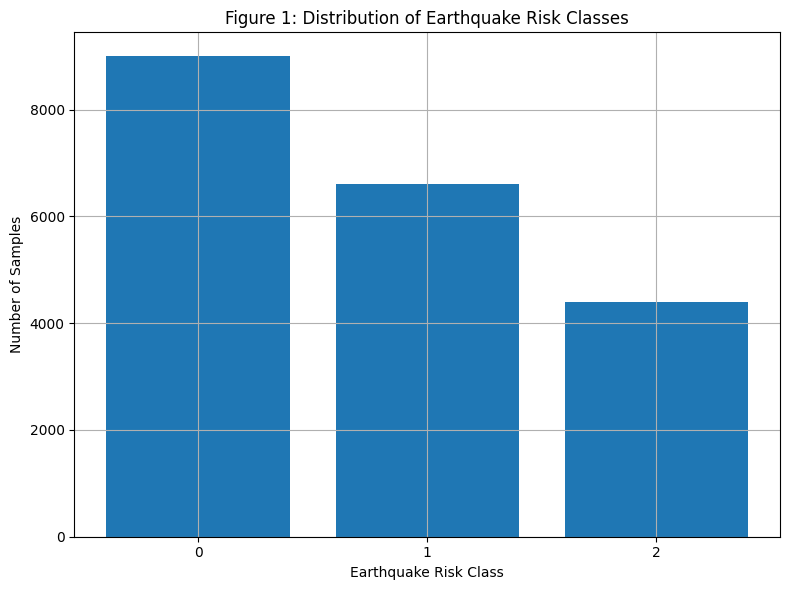

Class proportions:
earthquake_risk
0    45.0
1    33.0
2    22.0
Name: count, dtype: float64


In [31]:
target_counts = df["earthquake_risk"].value_counts().sort_index()

plt.figure(figsize=(8, 6))
plt.bar(
    target_counts.index.astype(str),
    target_counts.values
)
plt.xlabel("Earthquake Risk Class")
plt.ylabel("Number of Samples")
plt.title("Figure 1: Distribution of Earthquake Risk Classes")
plt.tight_layout()
plt.show()

print("Class proportions:")
print((target_counts / len(df) * 100).round(2))

Data preprocessing and missing-value handling

In [32]:
TARGET = "earthquake_risk"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()

imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X[numeric_features]),
    columns=numeric_features,
    index=X.index
)

print("Missing values after median imputation:")
print(X_imputed.isnull().sum().sum())

X = X_imputed.copy()

Missing values after median imputation:
0


Outlier analysis using IQR

In [33]:
iqr_summary = []

for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((X[col] < lower) | (X[col] > upper)).sum()

    iqr_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count,
        "Outlier Percentage": count / len(X) * 100
    })

iqr_df = pd.DataFrame(iqr_summary)

display(
    iqr_df.sort_values(
        "Outlier Percentage",
        ascending=False
    )
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
17,seismic_ratio,1.895765e-01,6.444990e-01,4.549225e-01,-4.928073e-01,1.326883e+00,1609,8.045
8,pga,1.497150e-02,3.614050e-02,2.116900e-02,-1.678200e-02,6.789400e-02,1291,6.455
13,snr,3.461900e+00,7.286803e+00,3.824903e+00,-2.275454e+00,1.302416e+01,837,4.185
3,seismicity_rate,2.060760e+00,4.351632e+00,2.290872e+00,-1.375547e+00,7.787940e+00,803,4.015
15,distance_to_fault,4.733146e+00,1.345069e+01,8.717542e+00,-8.343167e+00,2.652700e+01,645,3.225
4,inter_event_time,4.839720e+00,1.358245e+01,8.742732e+00,-8.274379e+00,2.669655e+01,620,3.100
12,azimuthal_gap,2.426377e+01,6.429017e+01,4.002640e+01,-3.577583e+01,1.243298e+02,581,2.905
18,stress_index,1.199916e+00,1.612686e+00,4.127698e-01,5.807616e-01,2.231841e+00,322,1.610
5,coulomb_stress,7.321000e-03,1.267400e-02,5.353000e-03,-7.085000e-04,2.070350e-02,149,0.745
6,magnitude,3.499746e+00,3.949872e+00,4.501258e-01,2.824558e+00,4.625061e+00,143,0.715


Figure 2: Box plots for outlier visualization

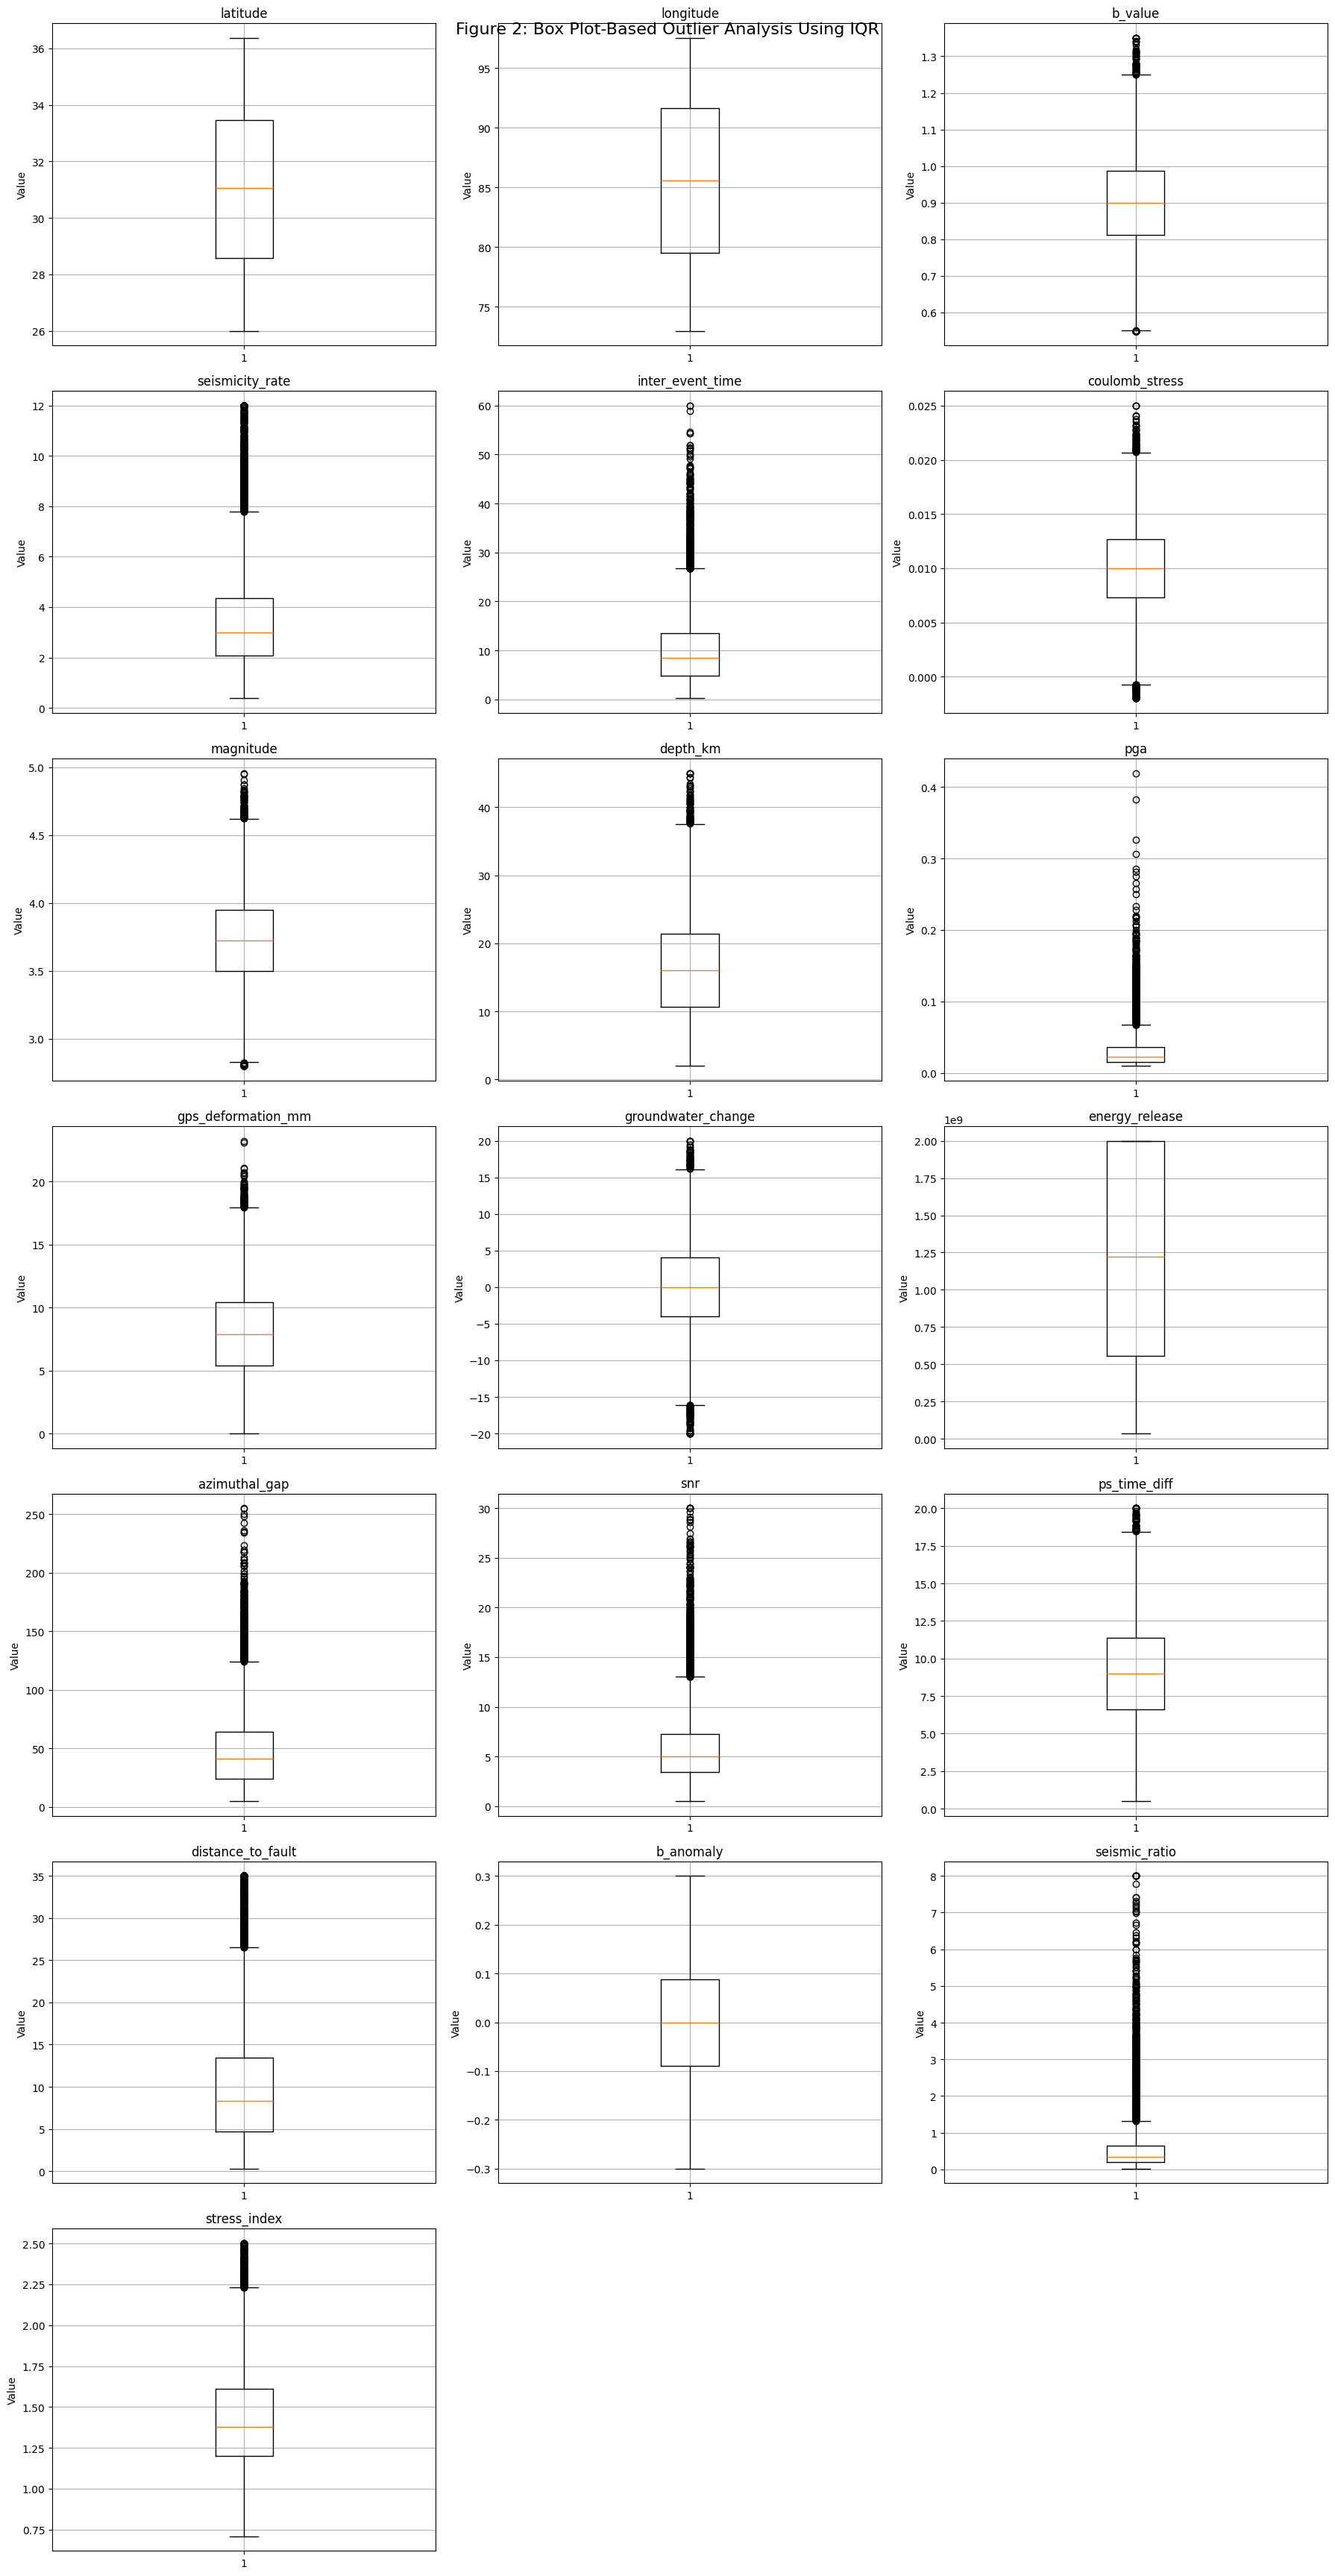

In [34]:
n_features = len(X.columns)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, col in enumerate(X.columns):
    axes[i].boxplot(X[col].dropna(), vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Figure 2: Box Plot-Based Outlier Analysis Using IQR",
    fontsize=16
)

plt.tight_layout()
plt.show()

Z-score outlier analysis

In [35]:
from scipy.stats import zscore

z_scores = pd.DataFrame(
    np.abs(zscore(X, nan_policy="omit")),
    columns=X.columns
)

z_summary = pd.DataFrame({
    "Feature": X.columns,
    "Z-score Outliers": [
        (z_scores[col] > 3).sum()
        for col in X.columns
    ]
})

z_summary["Percentage"] = (
    z_summary["Z-score Outliers"] /
    len(X) * 100
)

display(
    z_summary.sort_values(
        "Percentage",
        ascending=False
    )
)

,Feature,Z-score Outliers,Percentage
17,seismic_ratio,409,2.045
8,pga,402,2.010
3,seismicity_rate,353,1.765
13,snr,332,1.660
15,distance_to_fault,324,1.620
4,inter_event_time,274,1.370
12,azimuthal_gap,270,1.350
18,stress_index,139,0.695
10,groundwater_change,53,0.265
5,coulomb_stress,52,0.260


Robust outlier treatment

In [36]:
X_clean = X.copy()

for col in X_clean.columns:

    Q1 = X_clean[col].quantile(0.25)
    Q3 = X_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR

    mean = X_clean[col].mean()
    std = X_clean[col].std()

    lower_z = mean - 3 * std
    upper_z = mean + 3 * std

    lower_bound = max(
        X_clean[col].min(),
        lower_iqr
    )

    upper_bound = min(
        X_clean[col].max(),
        upper_iqr
    )

    X_clean[col] = X_clean[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("IQR/Z-score based robust outlier treatment completed.")

IQR/Z-score based robust outlier treatment completed.


Train-test split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training samples: (16000, 19)
Testing samples: (4000, 19)

Training class distribution:
earthquake_risk
0    7200
1    5280
2    3520
Name: count, dtype: int64

Testing class distribution:
earthquake_risk
0    1800
1    1320
2     880
Name: count, dtype: int64


Figure 3: Correlation Matrix of Input Features

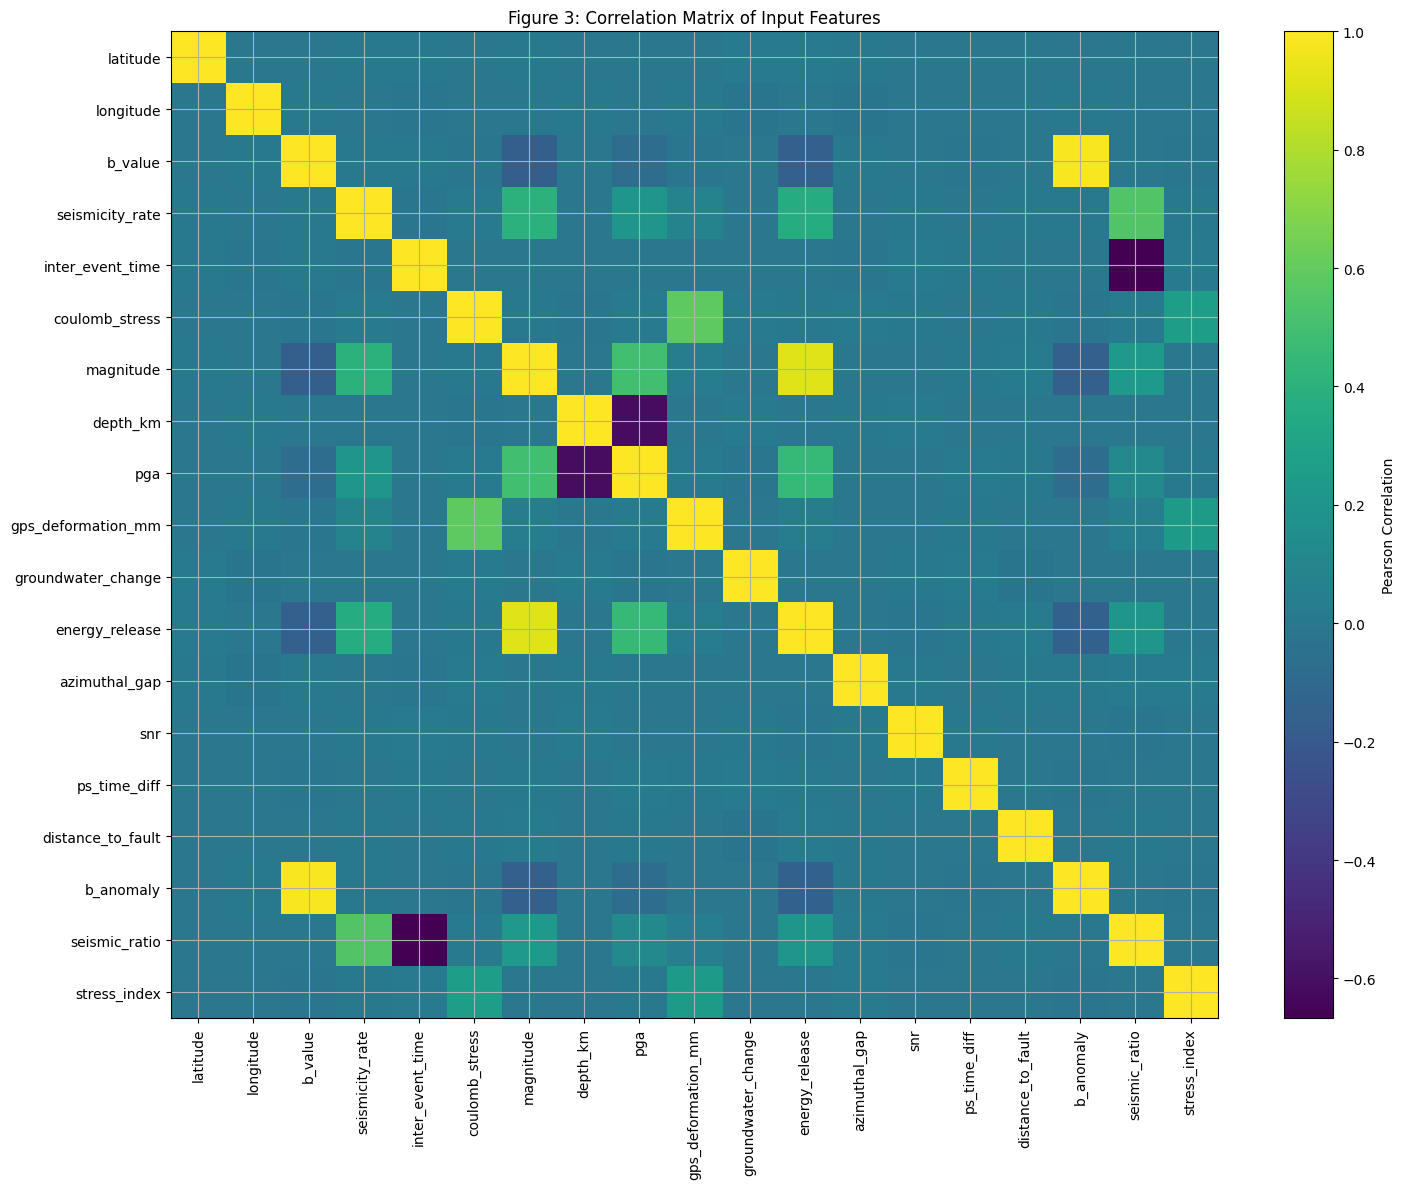

In [38]:
corr_input = X_train.corr(method="pearson")

plt.figure(figsize=(15, 12))
plt.imshow(
    corr_input,
    aspect="auto"
)

plt.colorbar(label="Pearson Correlation")

plt.xticks(
    range(len(corr_input.columns)),
    corr_input.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_input.columns)),
    corr_input.columns
)

plt.title(
    "Figure 3: Correlation Matrix of Input Features"
)

plt.tight_layout()
plt.show()

Pearson and Spearman correlation analysis

In [39]:
pearson_corr = X_train.corr(method="pearson")
spearman_corr = X_train.corr(method="spearman")

upper_triangle = np.triu(
    np.ones(pearson_corr.shape),
    k=1
).astype(bool)

pearson_pairs = (
    pearson_corr.where(upper_triangle)
    .stack()
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

spearman_pairs = (
    spearman_corr.where(upper_triangle)
    .stack()
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

print("Top Pearson correlations:")
display(
    pearson_pairs.head(15).to_frame("Pearson r")
)

print("Top Spearman correlations:")
display(
    spearman_pairs.head(15).to_frame("Spearman rho")
)

Top Pearson correlations:


Pearson r
b_value            b_anomaly            0.980876
magnitude          energy_release       0.919148
inter_event_time   seismic_ratio       -0.667312
depth_km           pga                 -0.608712
coulomb_stress     gps_deformation_mm   0.588654
seismicity_rate    seismic_ratio        0.548535
magnitude          pga                  0.497298
pga                energy_release       0.450404
seismicity_rate    magnitude            0.404164
                   energy_release       0.365444
coulomb_stress     stress_index         0.261189
gps_deformation_mm stress_index         0.240581
magnitude          seismic_ratio        0.225276
energy_release     seismic_ratio        0.204991
seismicity_rate    pga                  0.203874

Top Spearman correlations:


Spearman rho
b_value            b_anomaly               0.979805
magnitude          energy_release          0.970664
inter_event_time   seismic_ratio          -0.778207
depth_km           pga                    -0.604944
seismicity_rate    seismic_ratio           0.592594
coulomb_stress     gps_deformation_mm      0.571938
magnitude          pga                     0.541033
pga                energy_release          0.516966
seismicity_rate    magnitude               0.397519
                   energy_release          0.379972
coulomb_stress     stress_index            0.265300
gps_deformation_mm stress_index            0.247545
magnitude          seismic_ratio           0.239124
energy_release     seismic_ratio           0.227497
seismicity_rate    pga                     0.223905

Correlation with earthquake risk

In [40]:
target_corr = X_train.copy()
target_corr[TARGET] = y_train.values

pearson_target = (
    target_corr.corr(method="pearson")[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

spearman_target = (
    target_corr.corr(method="spearman")[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

correlation_analysis = pd.DataFrame({
    "Feature": pearson_target.index,
    "Pearson": pearson_target.values,
    "Spearman": spearman_target.reindex(
        pearson_target.index
    ).values
})

display(correlation_analysis)

,Feature,Pearson,Spearman
0,seismicity_rate,0.682223,0.678163
1,seismic_ratio,0.631768,0.610514
2,magnitude,0.490844,0.491640
3,energy_release,0.461475,0.470170
4,pga,0.324505,0.341085
5,inter_event_time,-0.232277,-0.249806
6,stress_index,0.192302,0.189543
7,gps_deformation_mm,0.181741,0.177304
8,distance_to_fault,-0.152154,-0.145803
9,coulomb_stress,0.114790,0.112814


Correlation-based feature selection

In [41]:
CORRELATION_THRESHOLD = 0.90

corr_abs = X_train.corr().abs()

upper = corr_abs.where(
    np.triu(
        np.ones(corr_abs.shape),
        k=1
    ).astype(bool)
)

high_corr_features = [
    column
    for column in upper.columns
    if any(
        upper[column] > CORRELATION_THRESHOLD
    )
]

print(
    "Highly correlated features removed:",
    high_corr_features
)

X_train_corr = X_train.drop(
    columns=high_corr_features
)

X_test_corr = X_test.drop(
    columns=high_corr_features
)

print(
    "Features remaining after correlation filtering:",
    X_train_corr.shape[1]
)

Highly correlated features removed: ['energy_release', 'b_anomaly']
Features remaining after correlation filtering: 17


PCA analysis

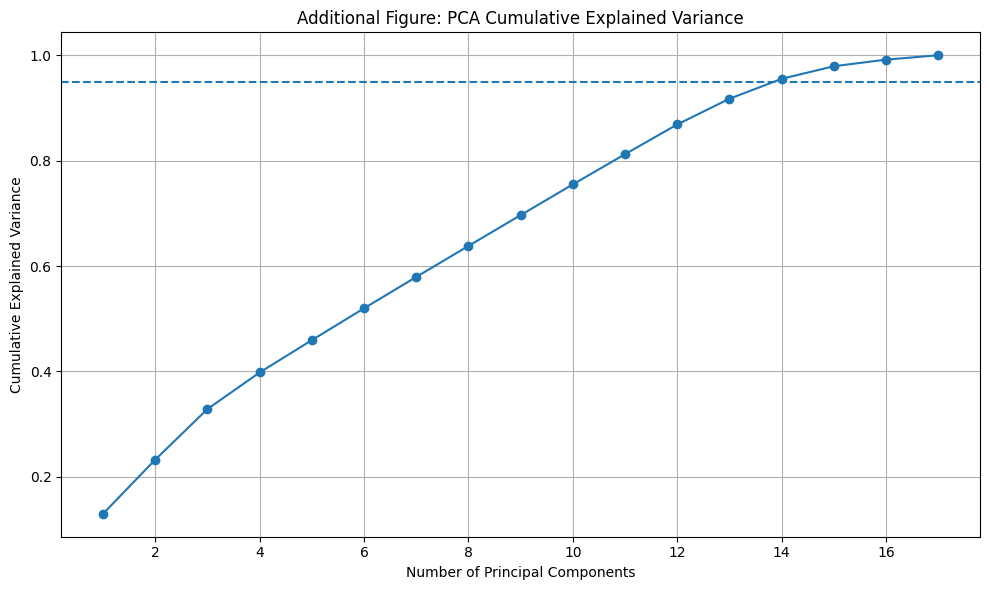

Components required for 95% variance: 14


In [42]:
scaler_pca = StandardScaler()

X_train_scaled = scaler_pca.fit_transform(X_train_corr)
X_test_scaled = scaler_pca.transform(X_test_corr)

pca_full = PCA()

pca_full.fit(X_train_scaled)

explained_variance = (
    pca_full.explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    explained_variance
)

plt.figure(figsize=(10, 6))

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.95,
    linestyle="--"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title(
    "Additional Figure: PCA Cumulative Explained Variance"
)

plt.tight_layout()
plt.show()

n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Components required for 95% variance:",
    n_components_95
)

PCA-transformed selected feature space

In [43]:
pca = PCA(
    n_components=n_components_95,
    random_state=RANDOM_STATE
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

pca_columns = [
    f"PC{i+1}"
    for i in range(n_components_95)
]

X_train_pca = pd.DataFrame(
    X_train_pca,
    columns=pca_columns,
    index=X_train_corr.index
)

X_test_pca = pd.DataFrame(
    X_test_pca,
    columns=pca_columns,
    index=X_test_corr.index
)

print(
    "PCA training shape:",
    X_train_pca.shape
)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

PCA training shape: (16000, 14)
Explained variance: [0.12977063 0.10271479 0.09605521 0.06941271 0.06133674 0.06043624
 0.05954544 0.05880398 0.05850482 0.05834609 0.05732832 0.05643907
 0.04875715 0.03777943]
Total explained variance: 0.9552306372862466


Figure 4: Correlation Matrix of Selected Features

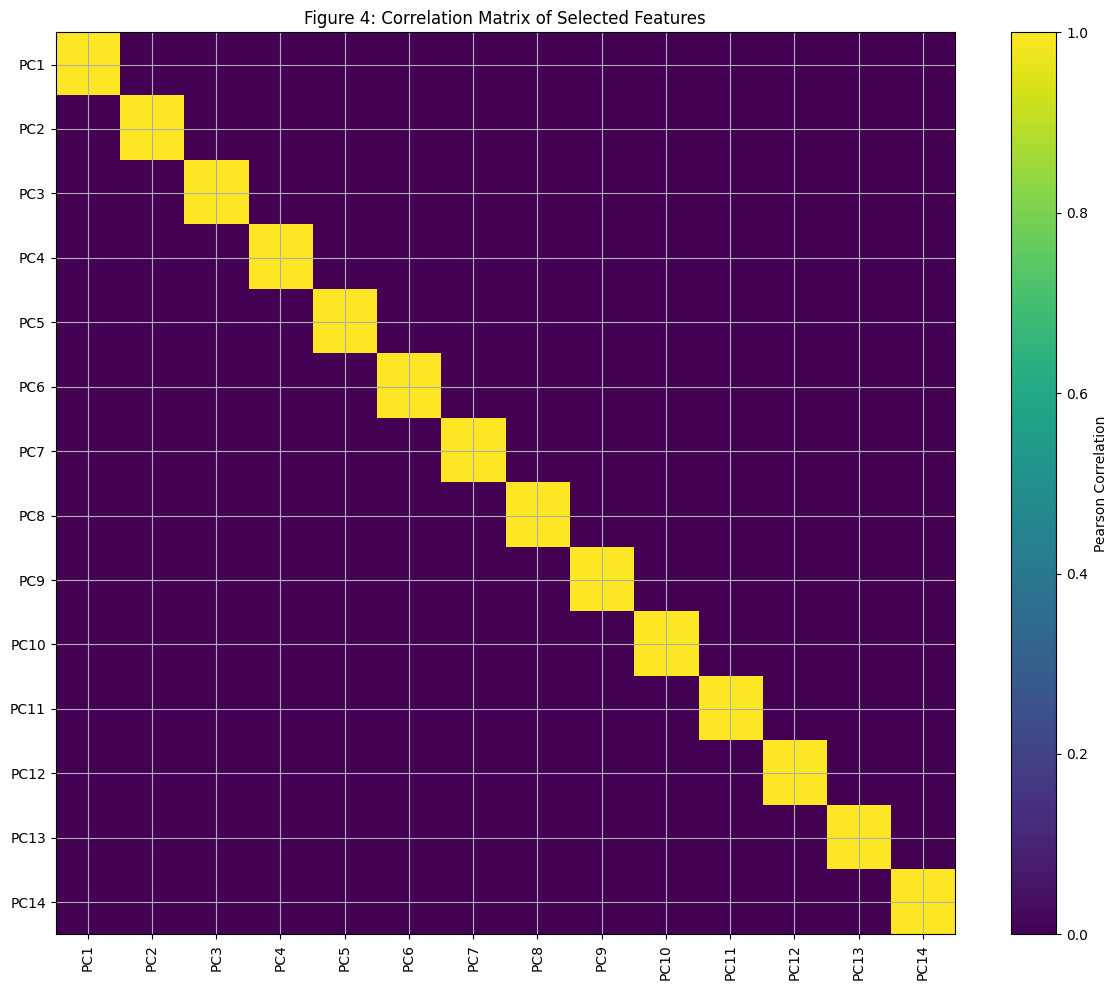

In [44]:
selected_features = X_train_pca.columns.tolist()

corr_selected = X_train_pca.corr()

plt.figure(figsize=(12, 10))

plt.imshow(
    corr_selected,
    aspect="auto"
)

plt.colorbar(
    label="Pearson Correlation"
)

plt.xticks(
    range(len(selected_features)),
    selected_features,
    rotation=90
)

plt.yticks(
    range(len(selected_features)),
    selected_features
)

plt.title(
    "Figure 4: Correlation Matrix of Selected Features"
)

plt.tight_layout()
plt.show()

Figure 5: PCA feature contribution

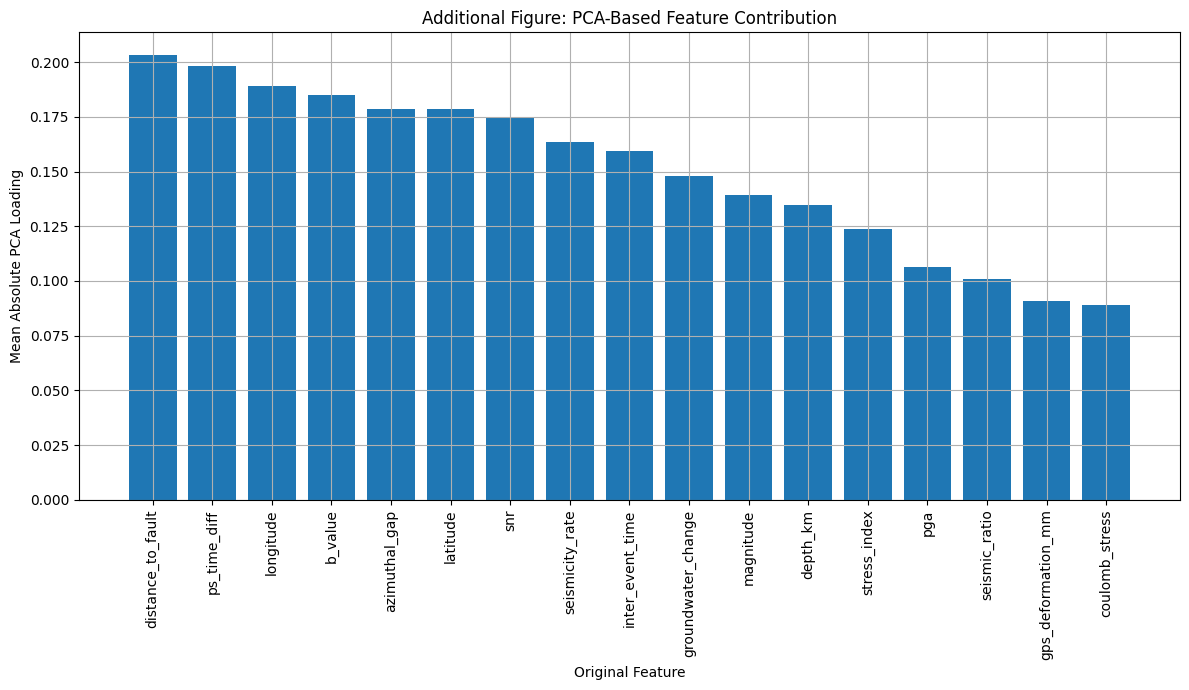

In [45]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=pca_columns,
    index=X_train_corr.columns
)

feature_contribution = (
    loadings.abs().mean(axis=1)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

plt.bar(
    feature_contribution.index,
    feature_contribution.values
)

plt.xticks(
    rotation=90
)

plt.ylabel("Mean Absolute PCA Loading")
plt.xlabel("Original Feature")

plt.title(
    "Additional Figure: PCA-Based Feature Contribution"
)

plt.tight_layout()
plt.show()

SMOTE balancing

In [46]:
smote = SMOTE(
    random_state=RANDOM_STATE
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_pca,
    y_train
)

print("Original training distribution:")
print(y_train.value_counts().sort_index())

print("\nBalanced training distribution:")
print(
    pd.Series(
        y_train_balanced
    ).value_counts().sort_index()
)

Original training distribution:
earthquake_risk
0    7200
1    5280
2    3520
Name: count, dtype: int64

Balanced training distribution:
earthquake_risk
0    7200
1    7200
2    7200
Name: count, dtype: int64


Figure: SMOTE class distribution

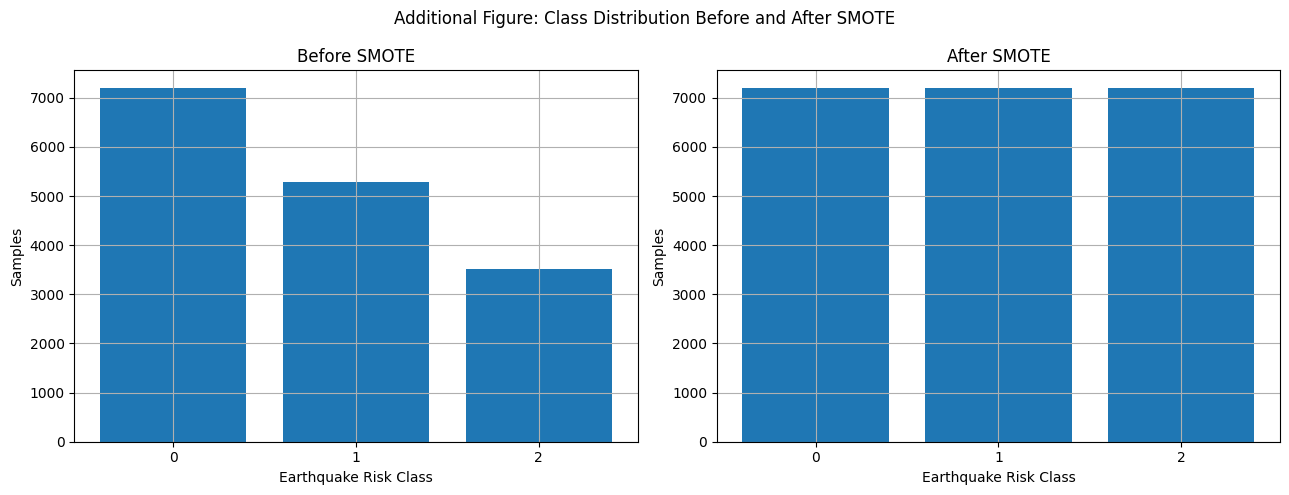

In [47]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

original_counts = y_train.value_counts().sort_index()
balanced_counts = pd.Series(
    y_train_balanced
).value_counts().sort_index()

axes[0].bar(
    original_counts.index.astype(str),
    original_counts.values
)

axes[0].set_title(
    "Before SMOTE"
)

axes[0].set_xlabel(
    "Earthquake Risk Class"
)

axes[0].set_ylabel(
    "Samples"
)

axes[1].bar(
    balanced_counts.index.astype(str),
    balanced_counts.values
)

axes[1].set_title(
    "After SMOTE"
)

axes[1].set_xlabel(
    "Earthquake Risk Class"
)

axes[1].set_ylabel(
    "Samples"
)

fig.suptitle(
    "Additional Figure: Class Distribution Before and After SMOTE"
)

plt.tight_layout()
plt.show()

In [48]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),

    "SVM-RBF": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        verbosity=-1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=400,
        depth=7,
        learning_rate=0.05,
        verbose=False,
        random_seed=RANDOM_STATE
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    )
}

print("Number of implemented classical ML algorithms:")
print(len(models))

print("\nAlgorithms:")
for name in models:
    print(name)

Number of implemented classical ML algorithms:
11

Algorithms:
Logistic Regression
KNN
SVM-RBF
Random Forest
XGBoost
LightGBM
CatBoost
Extra Trees
Hist Gradient Boosting
Gradient Boosting
AdaBoost


Train all models

In [49]:
def multiclass_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    specificities = []

    for i in range(cm.shape[0]):

        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        specificity = (
            TN / (TN + FP)
            if (TN + FP) > 0
            else 0
        )

        specificities.append(specificity)

    return np.mean(specificities)


results = []
predictions = {}
probabilities = {}
fitted_models = {}

classes = np.sort(y.unique())

for name, model in models.items():

    print(
        f"Training {name}..."
    )

    model.fit(
        X_train_balanced,
        y_train_balanced
    )

    y_pred = model.predict(
        X_test_pca
    )

    y_prob = model.predict_proba(
        X_test_pca
    )

    predictions[name] = y_pred
    probabilities[name] = y_prob
    fitted_models[name] = model

    y_test_bin = label_binarize(
        y_test,
        classes=classes
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    auc_score = roc_auc_score(
        y_test_bin,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    balanced_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    specificity = multiclass_specificity(
        y_test,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    ll = log_loss(
        y_test,
        y_prob,
        labels=classes
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": recall,
        "Recall": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "ROC-AUC": auc_score,
        "Balanced Accuracy": balanced_acc,
        "Cohen Kappa": kappa,
        "MCC": mcc,
        "Log Loss": ll
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    results_df.round(4)
)

Training Logistic Regression...
Training KNN...
Training SVM-RBF...
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training CatBoost...
Training Extra Trees...
Training Hist Gradient Boosting...
Training Gradient Boosting...
Training AdaBoost...


,Model,Accuracy,Precision,Sensitivity,Recall,Specificity,F1-score,ROC-AUC,Balanced Accuracy,Cohen Kappa,MCC,Log Loss
0,Logistic Regression,0.7775,0.7700,0.7752,0.7752,0.8861,0.7724,0.9162,0.7752,0.6538,0.6540,0.5021
1,CatBoost,0.7698,0.7632,0.7684,0.7684,0.8818,0.7656,0.9145,0.7684,0.6418,0.6419,0.5051
2,XGBoost,0.7655,0.7612,0.7642,0.7642,0.8798,0.7624,0.9122,0.7642,0.6354,0.6358,0.5166
3,SVM-RBF,0.7688,0.7628,0.7679,0.7679,0.8817,0.7651,0.9112,0.7679,0.6407,0.6410,0.5172
4,Hist Gradient Boosting,0.7662,0.7605,0.7655,0.7655,0.8799,0.7628,0.9110,0.7655,0.6364,0.6366,0.5233
5,LightGBM,0.7672,0.7628,0.7662,0.7662,0.8808,0.7642,0.9106,0.7662,0.6382,0.6386,0.5290
6,Gradient Boosting,0.7625,0.7577,0.7623,0.7623,0.8786,0.7596,0.9079,0.7623,0.6312,0.6316,0.5282
7,Extra Trees,0.7550,0.7493,0.7493,0.7493,0.8729,0.7493,0.9057,0.7493,0.6171,0.6172,0.5962
8,Random Forest,0.7555,0.7490,0.7529,0.7529,0.8738,0.7509,0.9021,0.7529,0.6189,0.6190,0.5650
9,KNN,0.7010,0.6928,0.7027,0.7027,0.8479,0.6967,0.8556,0.7027,0.5376,0.5383,1.8411


Figure 6: Classification performance metrics

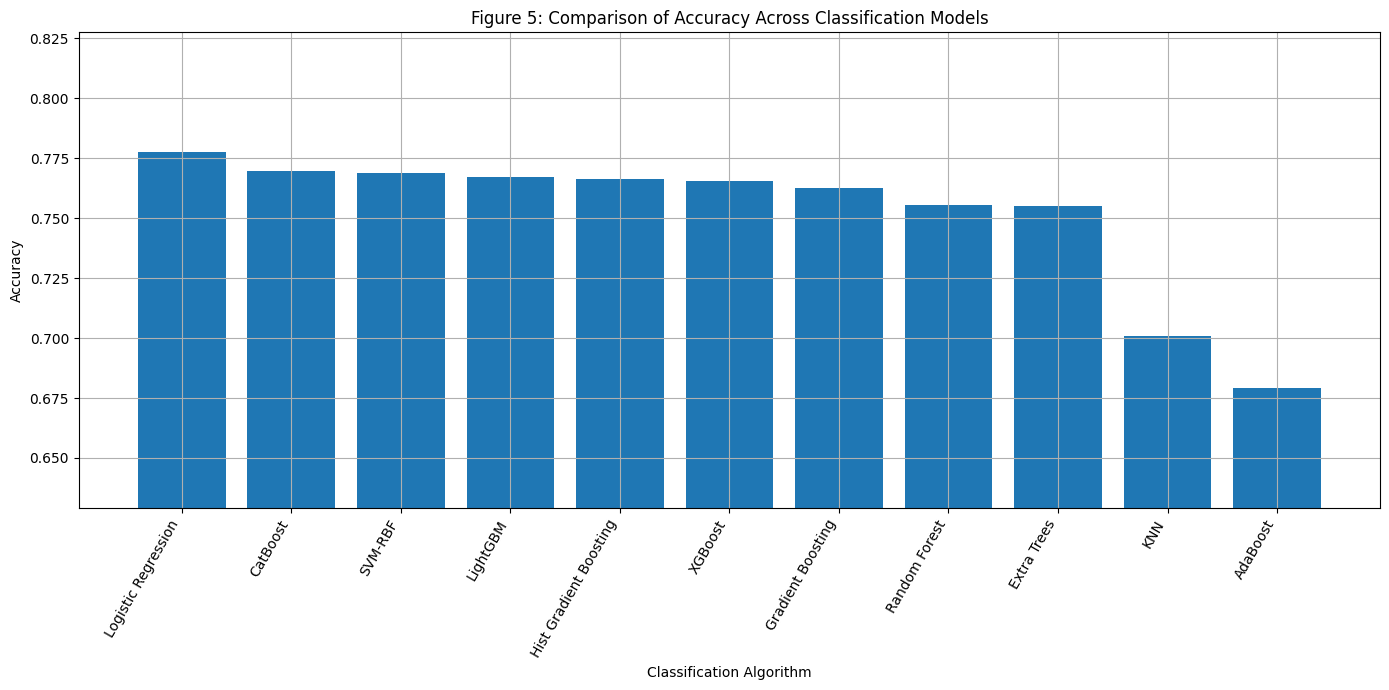

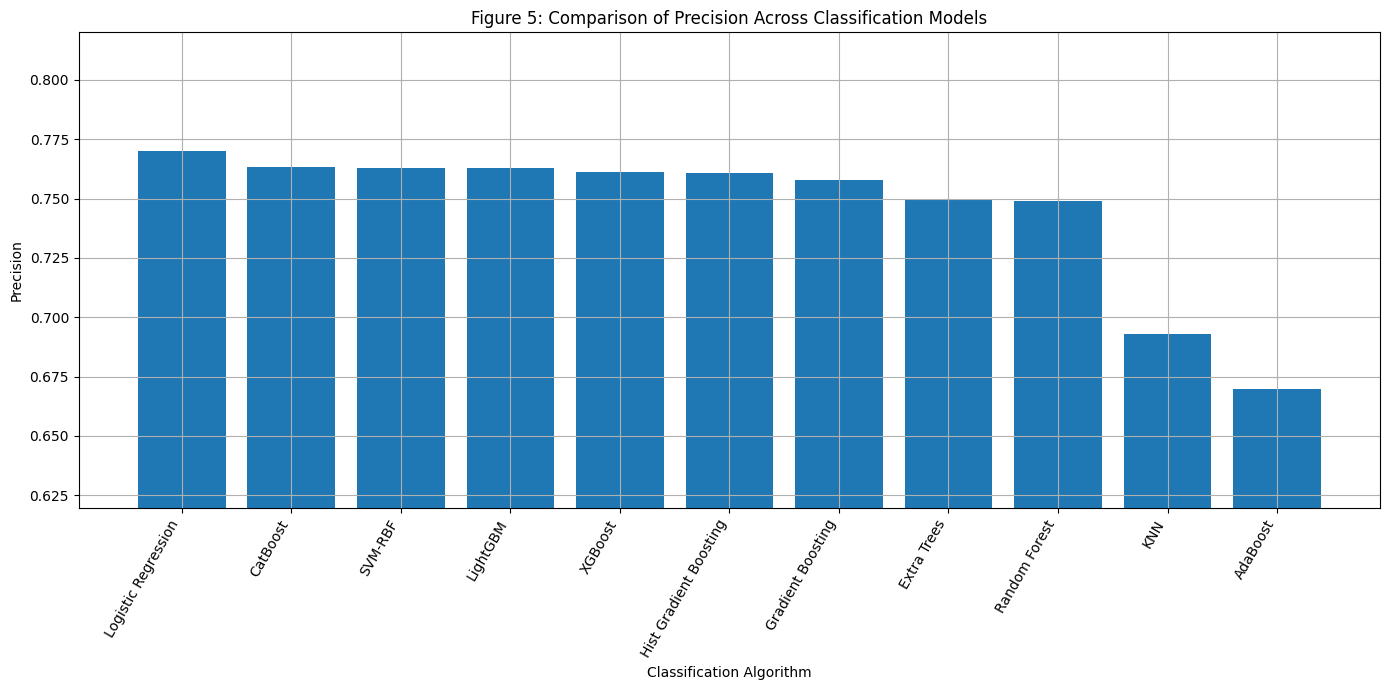

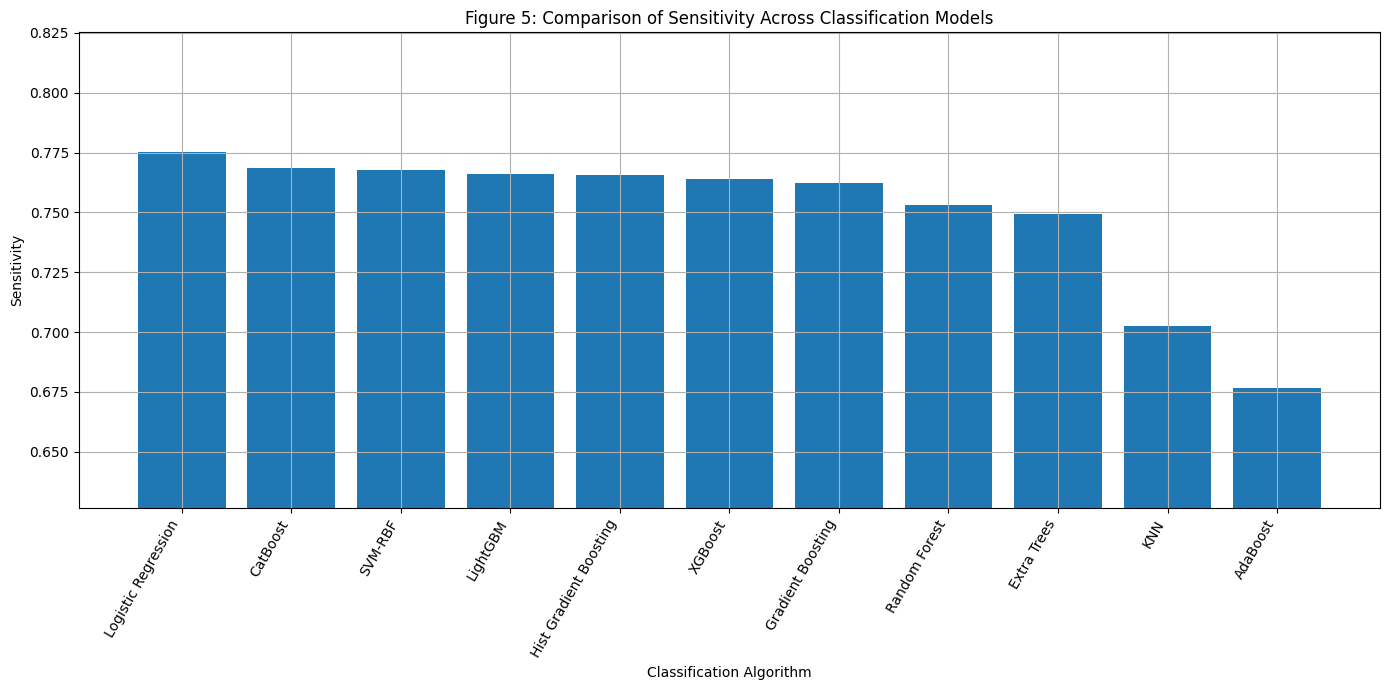

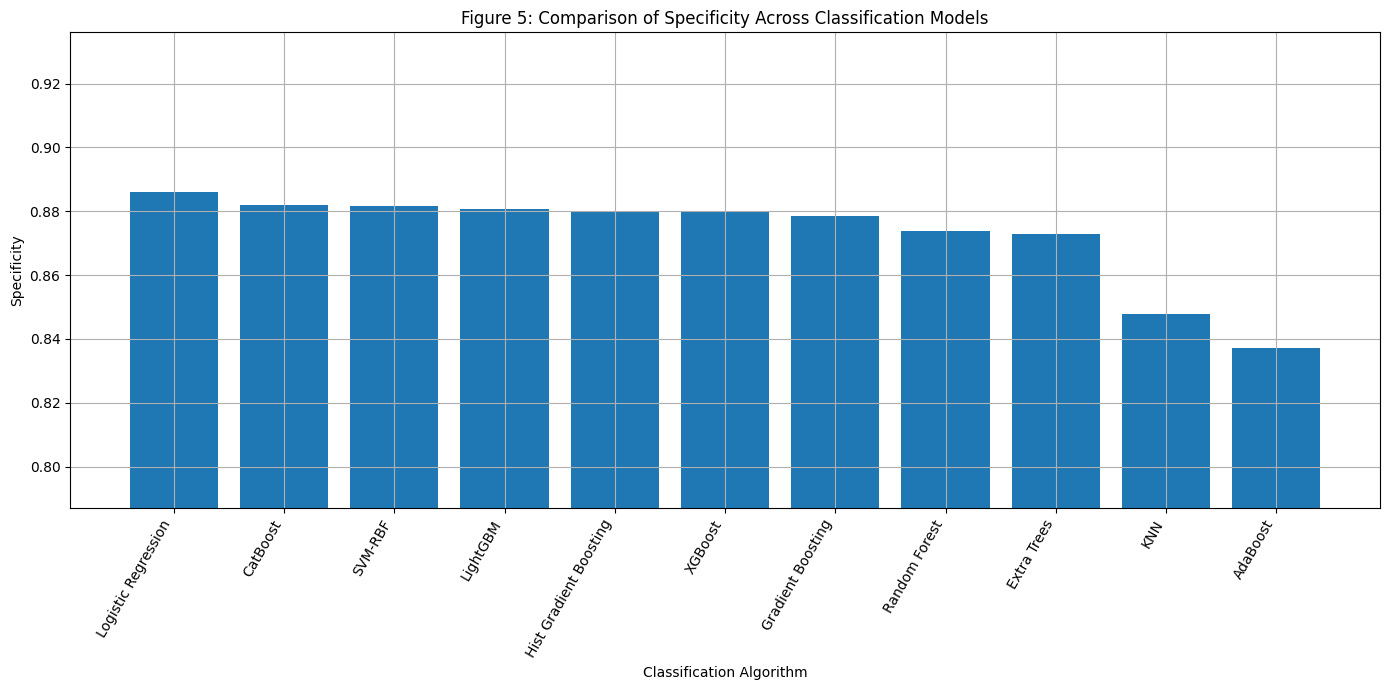

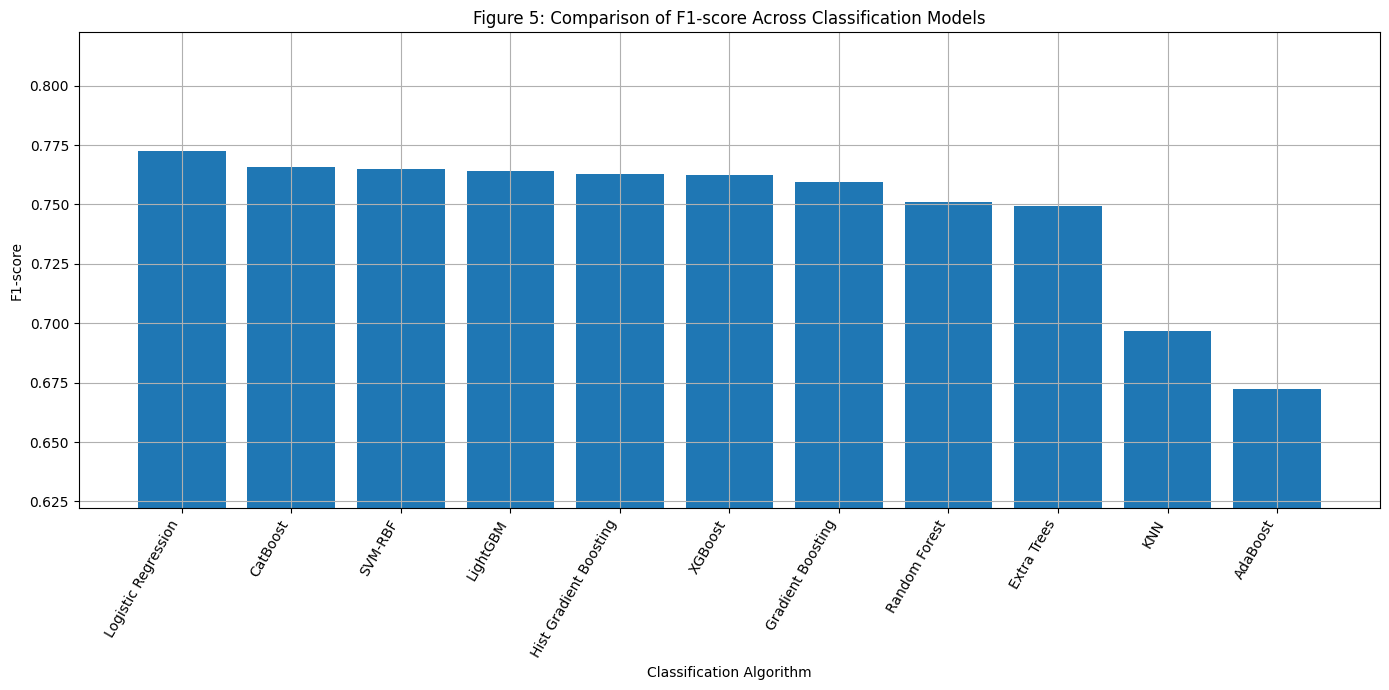

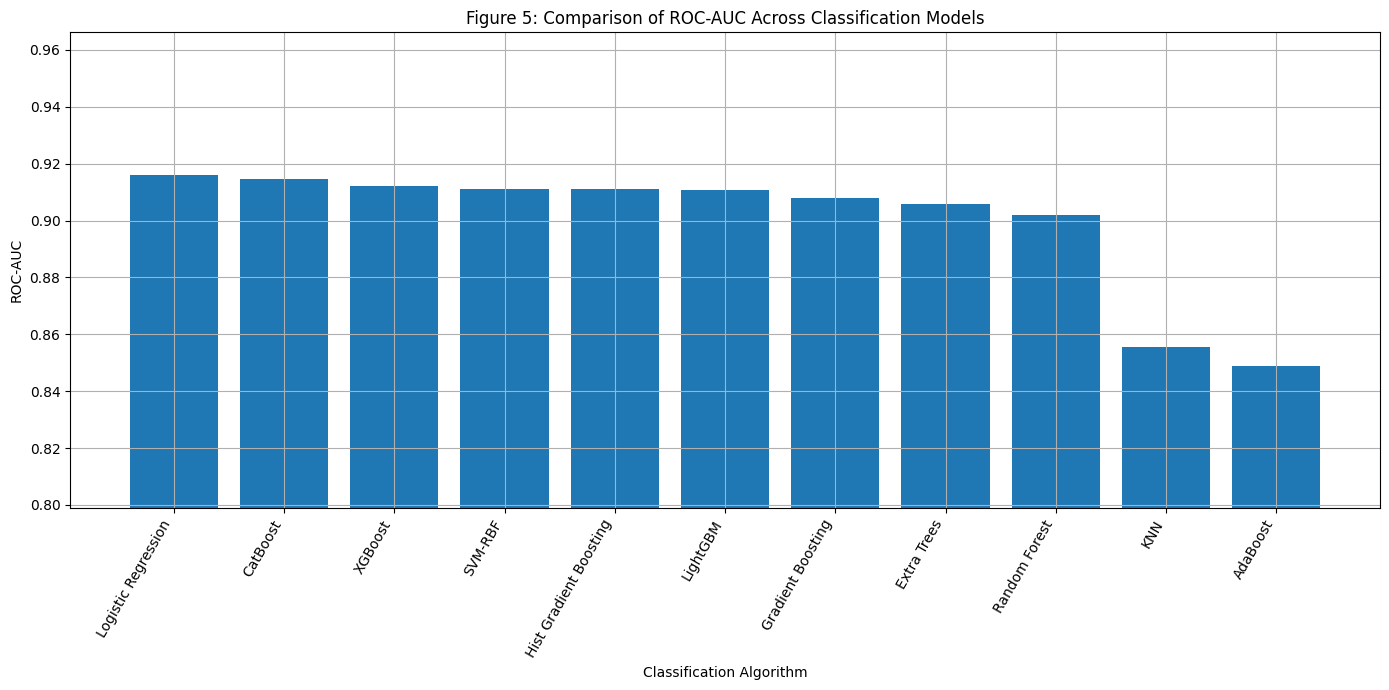

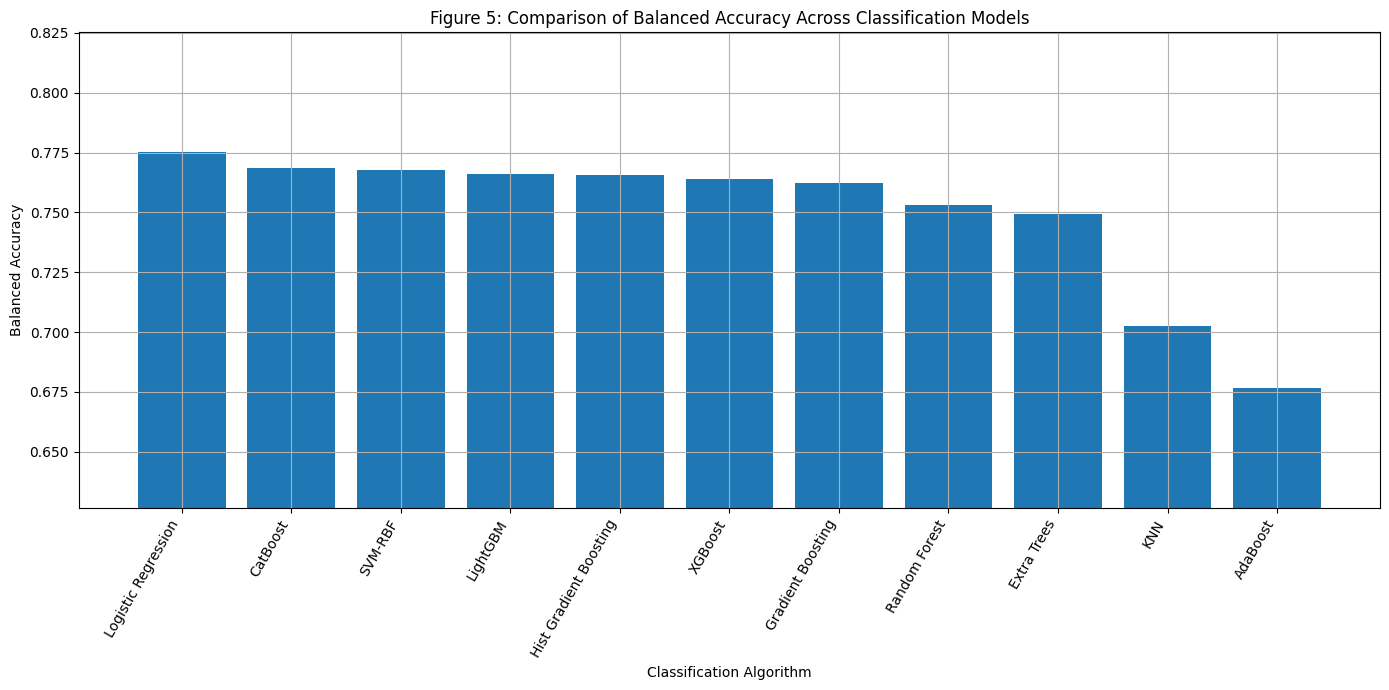

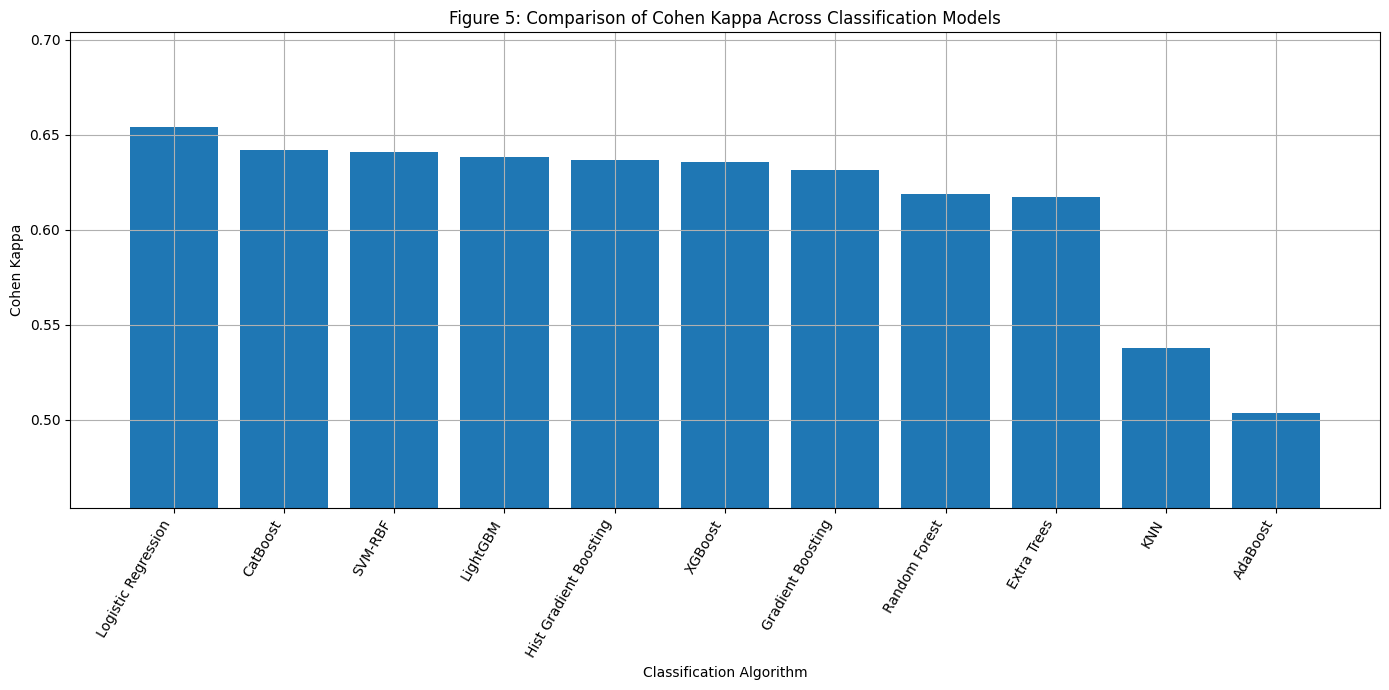

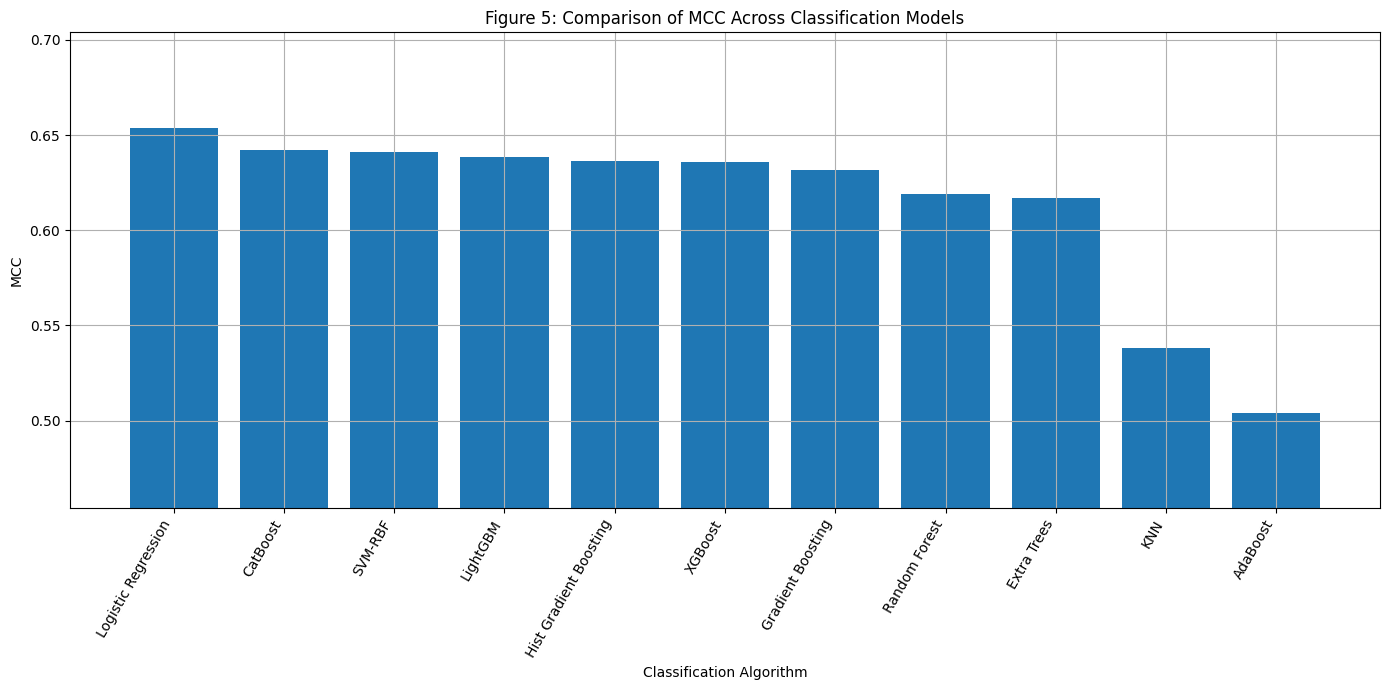

In [50]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1-score",
    "ROC-AUC",
    "Balanced Accuracy",
    "Cohen Kappa",
    "MCC"
]

for metric in metrics_to_plot:

    plt.figure(figsize=(14, 7))

    temp = results_df.sort_values(
        metric,
        ascending=False
    )

    plt.bar(
        temp["Model"],
        temp[metric]
    )

    plt.xticks(
        rotation=60,
        ha="right"
    )

    plt.ylabel(metric)

    plt.xlabel("Classification Algorithm")

    plt.title(
        f"Figure 5: Comparison of {metric} Across Classification Models"
    )

    plt.ylim(
        max(0, temp[metric].min() - 0.05),
        min(1.05, temp[metric].max() + 0.05)
    )

    plt.tight_layout()
    plt.show()

Combined performance graph

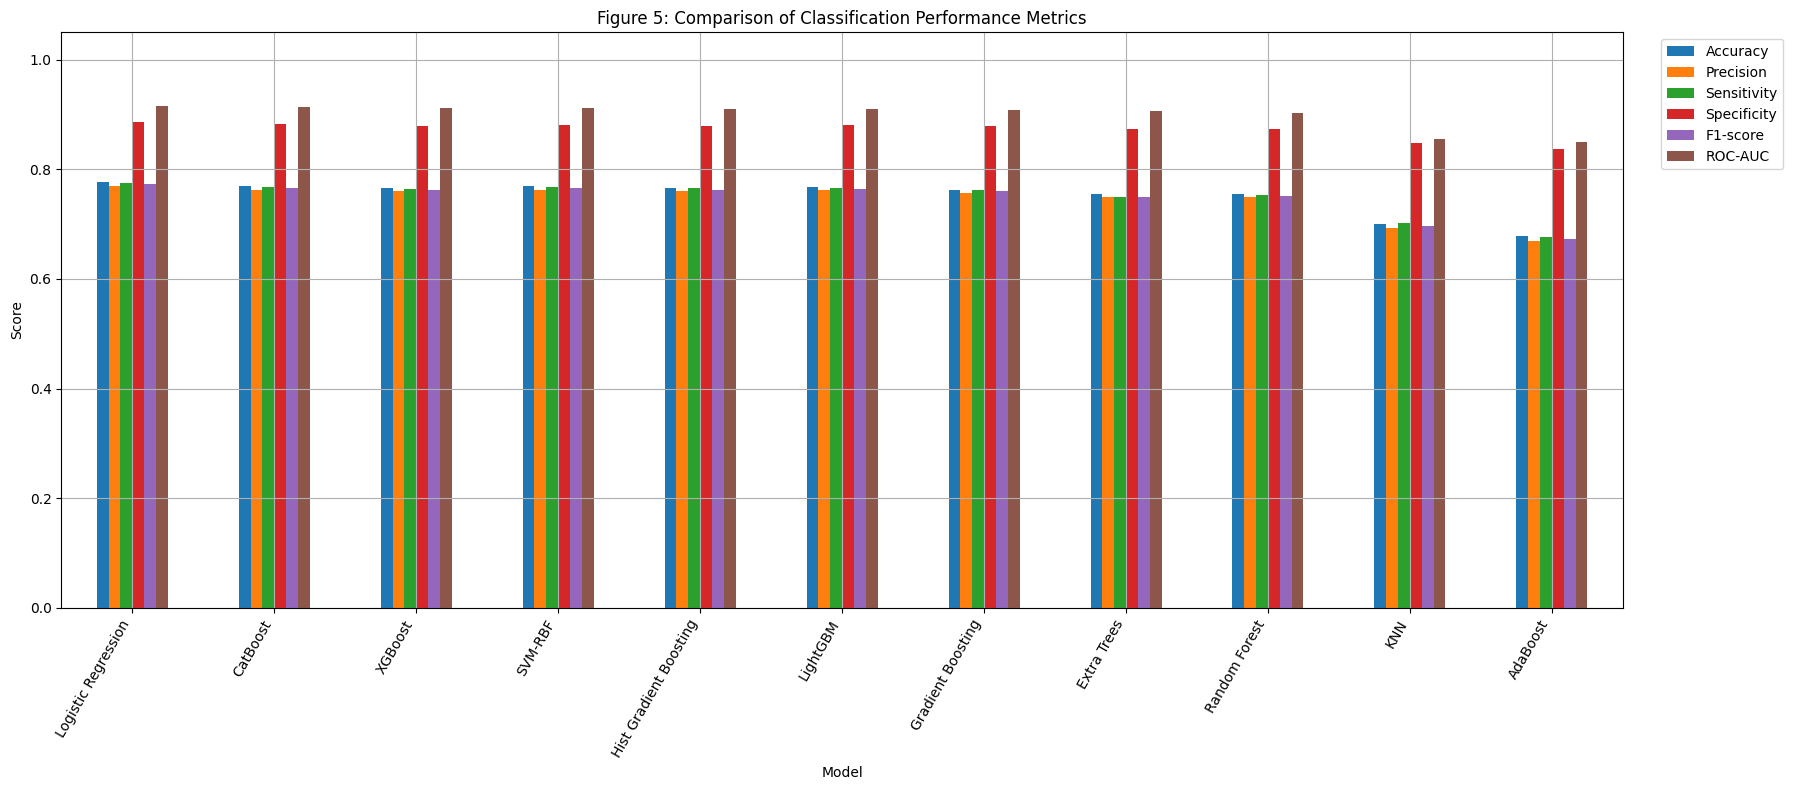

In [51]:
plot_df = results_df.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1-score",
        "ROC-AUC"
    ]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(18, 8)
)

ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_title(
    "Figure 5: Comparison of Classification Performance Metrics"
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.ylim(0, 1.05)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Figure 7: ROC curves and AUC comparison

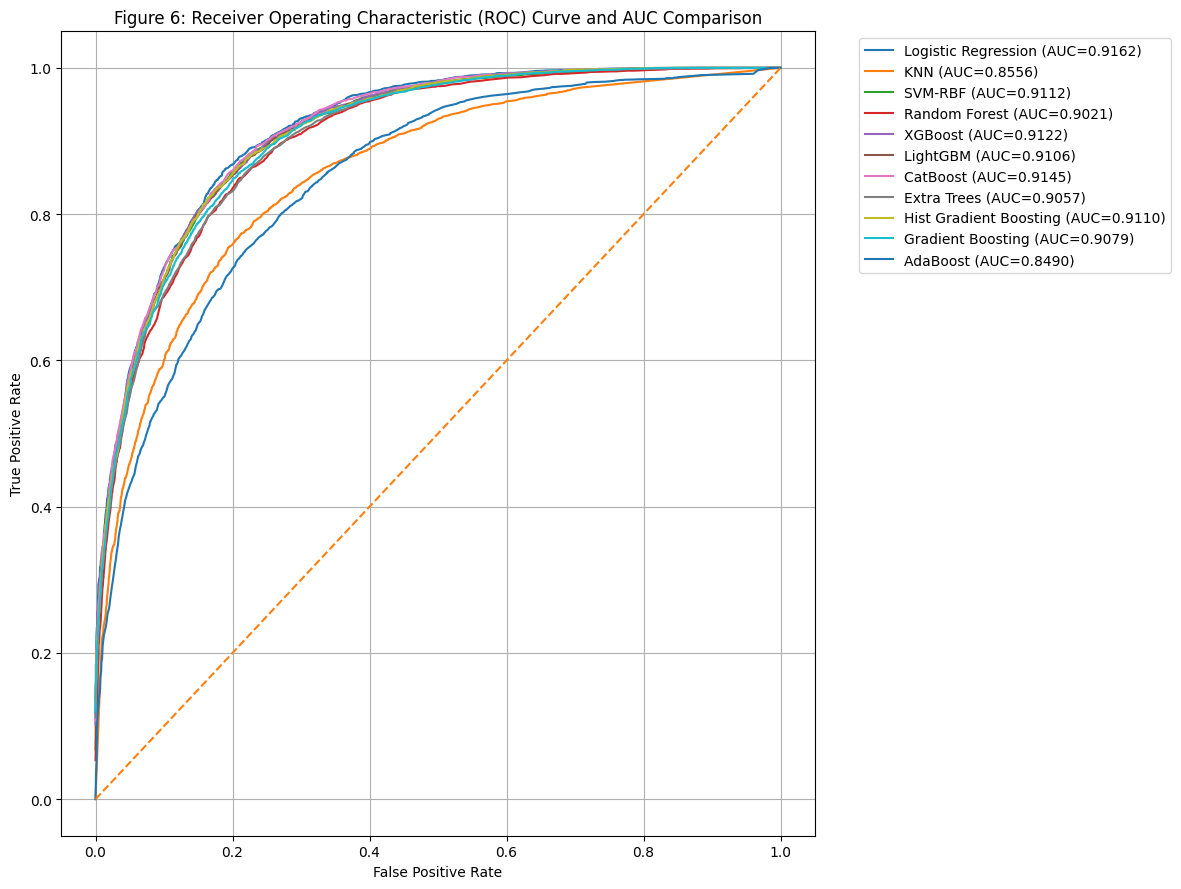

In [52]:
y_test_bin = label_binarize(
    y_test,
    classes=classes
)

plt.figure(figsize=(12, 9))

for name in models.keys():

    y_prob = probabilities[name]

    fpr = dict()
    tpr = dict()

    for i in range(len(classes)):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

    all_fpr = np.unique(
        np.concatenate(
            [
                fpr[i]
                for i in range(len(classes))
            ]
        )
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(len(classes)):
        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= len(classes)

    roc_auc_value = roc_auc_score(
        y_test_bin,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        label=f"{name} (AUC={roc_auc_value:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Figure 6: Receiver Operating Characteristic (ROC) Curve and AUC Comparison"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Figure 7: Model prediction outputs

In [53]:
prediction_df = pd.DataFrame(
    predictions,
    index=y_test.index
)

prediction_df["Actual"] = y_test.values

prediction_accuracy = {}

for model_name in models.keys():

    prediction_accuracy[model_name] = accuracy_score(
        y_test,
        prediction_df[model_name]
    )

prediction_accuracy_df = pd.DataFrame(
    prediction_accuracy.items(),
    columns=["Model", "Prediction Accuracy"]
).sort_values(
    "Prediction Accuracy",
    ascending=False
)

plt.figure(figsize=(15, 7))

plt.bar(
    prediction_accuracy_df["Model"],
    prediction_accuracy_df["Prediction Accuracy"]
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.ylabel(
    "Prediction Accuracy"
)

plt.xlabel(
    "Classification Model"
)

plt.title(
    "Figure 7: Comparison of Model Prediction Outputs"
)

plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

ValueError: Data must be 1-dimensional, got ndarray of shape (4000, 1) instead

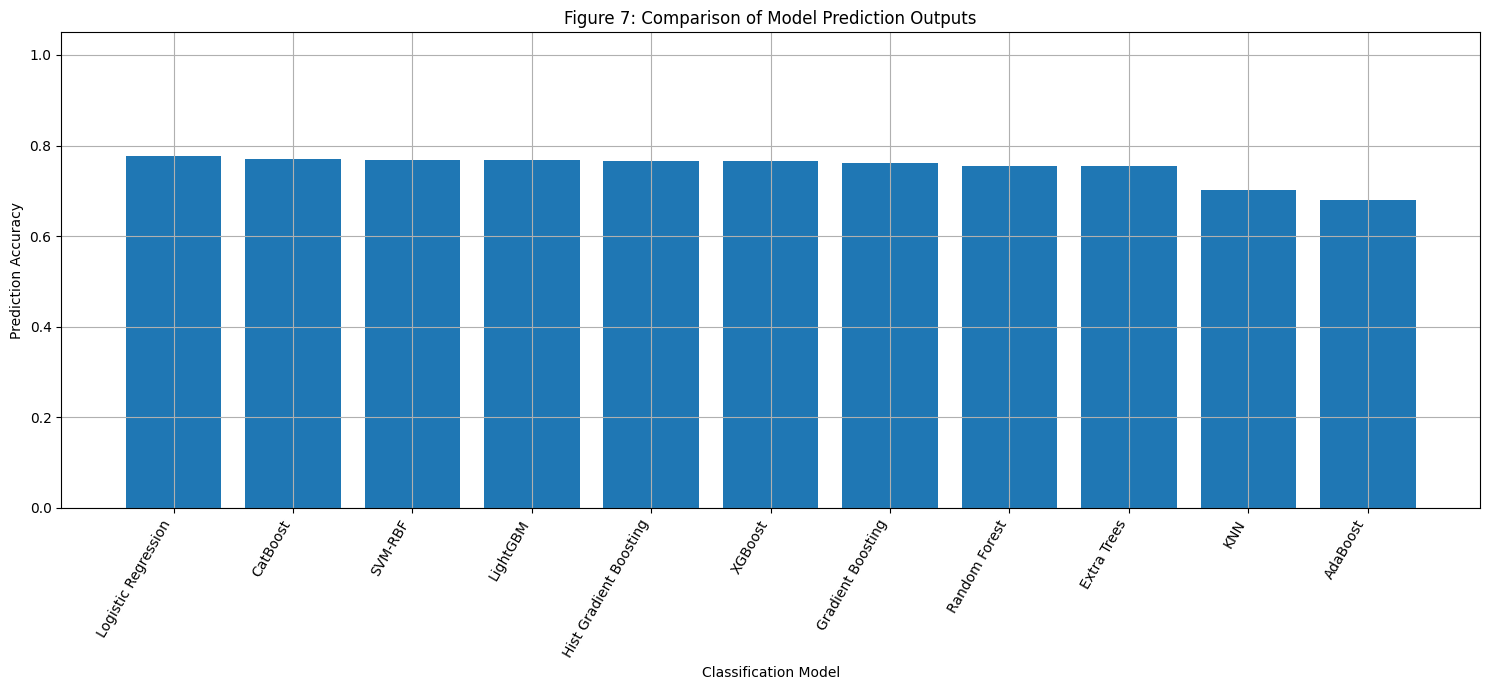

In [54]:
flattened_predictions = {}
for model_name, preds in predictions.items():
    if isinstance(preds, np.ndarray) and preds.ndim > 1 and preds.shape[1] == 1:
        flattened_predictions[model_name] = preds.flatten()
    else:
        flattened_predictions[model_name] = preds

prediction_df = pd.DataFrame(
    flattened_predictions,
    index=y_test.index
)

prediction_df["Actual"] = y_test.values

prediction_accuracy = {}

for model_name in models.keys():

    prediction_accuracy[model_name] = accuracy_score(
        y_test,
        prediction_df[model_name]
    )

prediction_accuracy_df = pd.DataFrame(
    prediction_accuracy.items(),
    columns=["Model", "Prediction Accuracy"]
).sort_values(
    "Prediction Accuracy",
    ascending=False
)

plt.figure(figsize=(15, 7))

plt.bar(
    prediction_accuracy_df["Model"],
    prediction_accuracy_df["Prediction Accuracy"]
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.ylabel(
    "Prediction Accuracy"
)

plt.xlabel(
    "Classification Model"
)

plt.title(
    "Figure 7: Comparison of Model Prediction Outputs"
)

plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

Figure 8: Correlation between model predictions

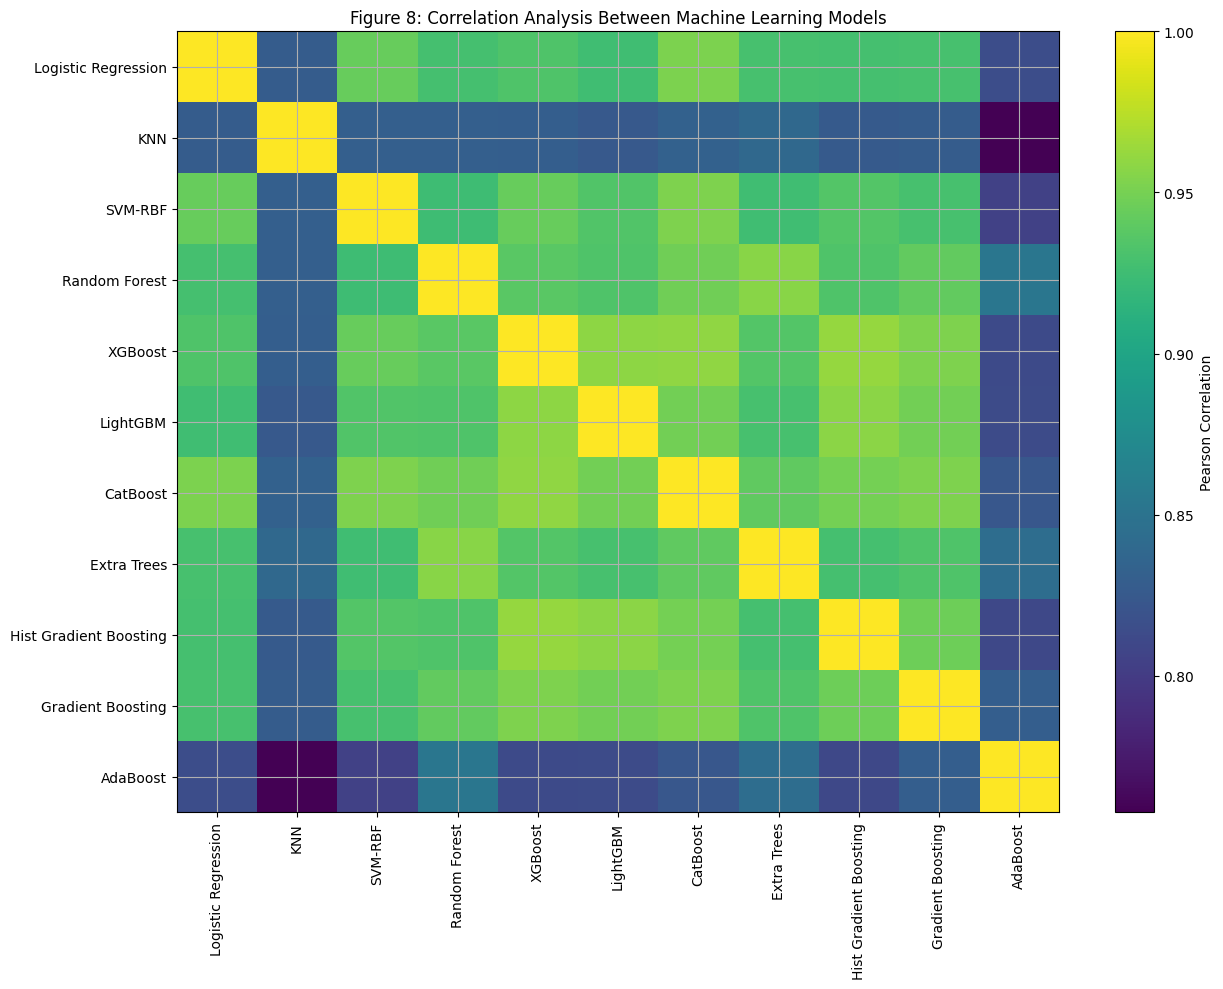

In [55]:
prediction_numeric = prediction_df.drop(
    columns=["Actual"]
)

model_prediction_corr = prediction_numeric.corr(
    method="pearson"
)

plt.figure(figsize=(13, 10))

plt.imshow(
    model_prediction_corr,
    aspect="auto"
)

plt.colorbar(
    label="Pearson Correlation"
)

plt.xticks(
    range(len(model_prediction_corr.columns)),
    model_prediction_corr.columns,
    rotation=90
)

plt.yticks(
    range(len(model_prediction_corr.columns)),
    model_prediction_corr.columns
)

plt.title(
    "Figure 8: Correlation Analysis Between Machine Learning Models"
)

plt.tight_layout()
plt.show()

Figure 9: Balanced vs imbalanced data

In [56]:
imbalanced_results = []

for name, model in models.items():

    imbalance_model = model.__class__(
        **model.get_params()
    )

    imbalance_model.fit(
        X_train_pca,
        y_train
    )

    pred = imbalance_model.predict(
        X_test_pca
    )

    imbalanced_results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            pred
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            pred
        ),
        "Sensitivity": recall_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        ),
        "Cohen Kappa": cohen_kappa_score(
            y_test,
            pred
        ),
        "MCC": matthews_corrcoef(
            y_test,
            pred
        )
    })

imbalanced_df = pd.DataFrame(
    imbalanced_results
)

balanced_comparison = results_df[
    [
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Sensitivity",
        "F1-score",
        "Cohen Kappa",
        "MCC"
    ]
].copy()

balanced_comparison["Dataset"] = "SMOTE Balanced"

imbalanced_df["Dataset"] = "Original Imbalanced"

comparison_all = pd.concat(
    [
        balanced_comparison,
        imbalanced_df
    ],
    ignore_index=True
)

display(
    comparison_all.round(4)
)

,Model,Accuracy,Balanced Accuracy,Sensitivity,F1-score,Cohen Kappa,MCC,Dataset
0,Logistic Regression,0.7775,0.7752,0.7752,0.7724,0.6538,0.6540,SMOTE Balanced
1,CatBoost,0.7698,0.7684,0.7684,0.7656,0.6418,0.6419,SMOTE Balanced
2,XGBoost,0.7655,0.7642,0.7642,0.7624,0.6354,0.6358,SMOTE Balanced
3,SVM-RBF,0.7688,0.7679,0.7679,0.7651,0.6407,0.6410,SMOTE Balanced
4,Hist Gradient Boosting,0.7662,0.7655,0.7655,0.7628,0.6364,0.6366,SMOTE Balanced
5,LightGBM,0.7672,0.7662,0.7662,0.7642,0.6382,0.6386,SMOTE Balanced
6,Gradient Boosting,0.7625,0.7623,0.7623,0.7596,0.6312,0.6316,SMOTE Balanced
7,Extra Trees,0.7550,0.7493,0.7493,0.7493,0.6171,0.6172,SMOTE Balanced
8,Random Forest,0.7555,0.7529,0.7529,0.7509,0.6189,0.6190,SMOTE Balanced
9,KNN,0.7010,0.7027,0.7027,0.6967,0.5376,0.5383,SMOTE Balanced


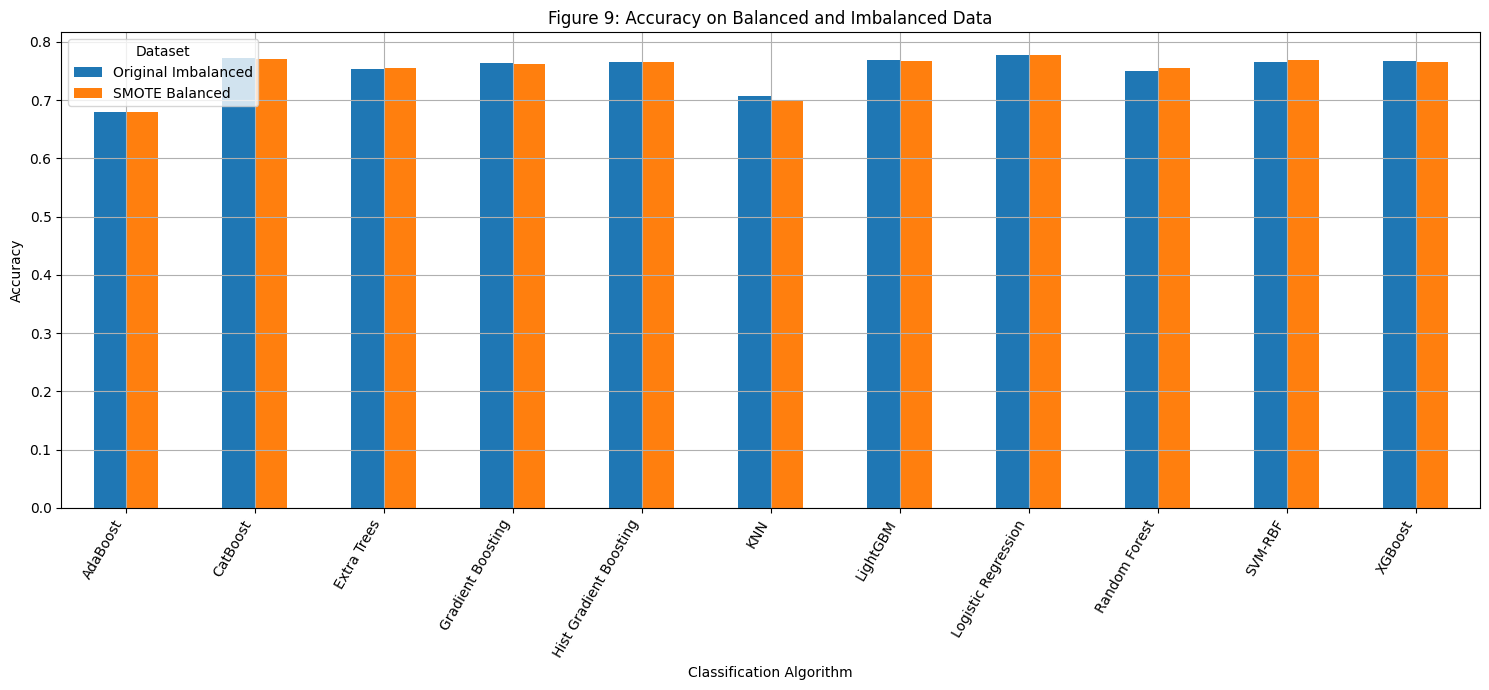

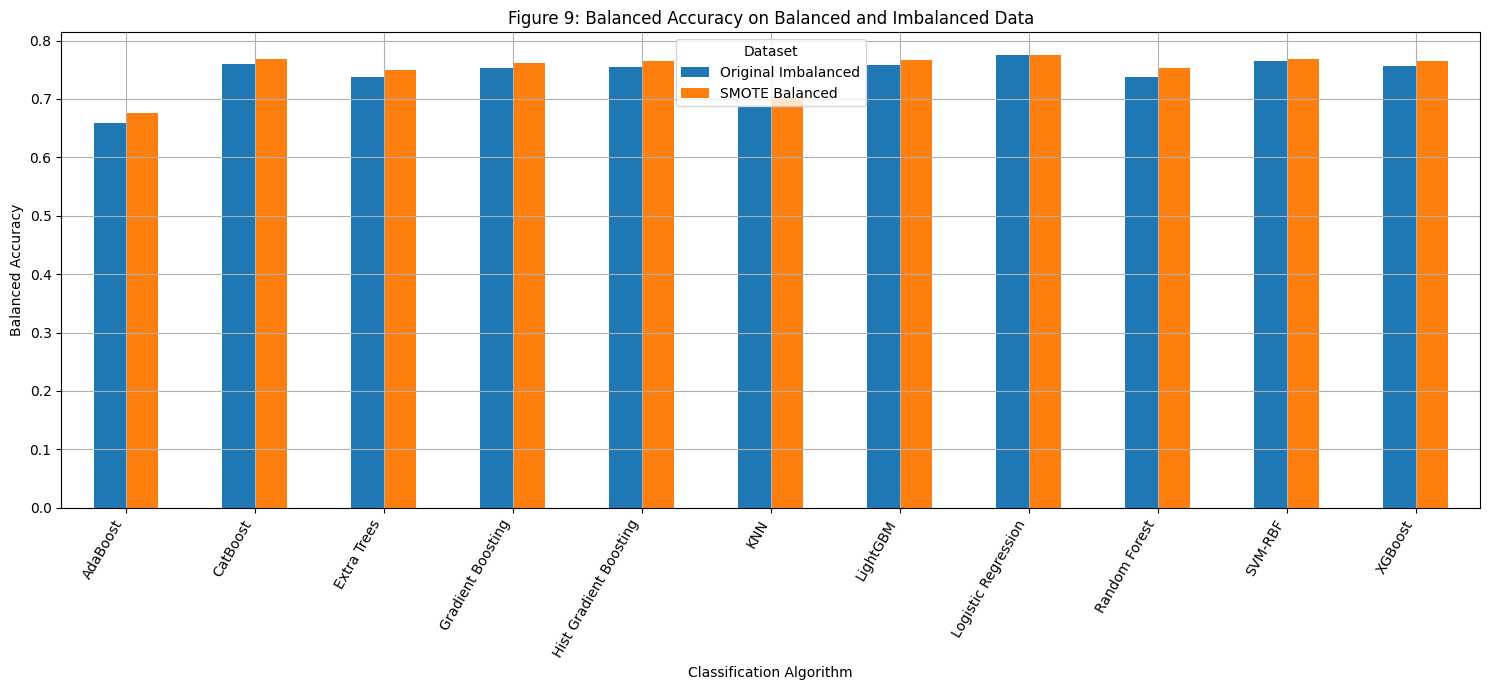

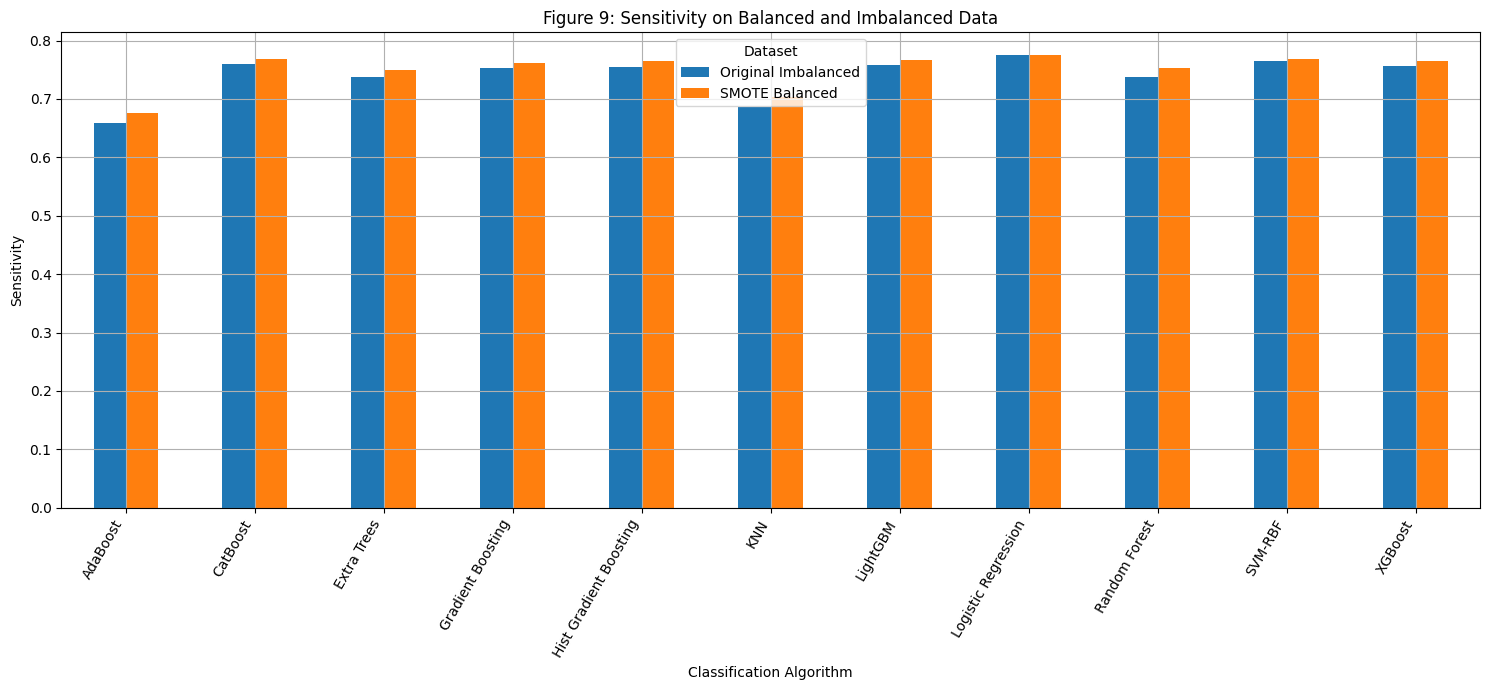

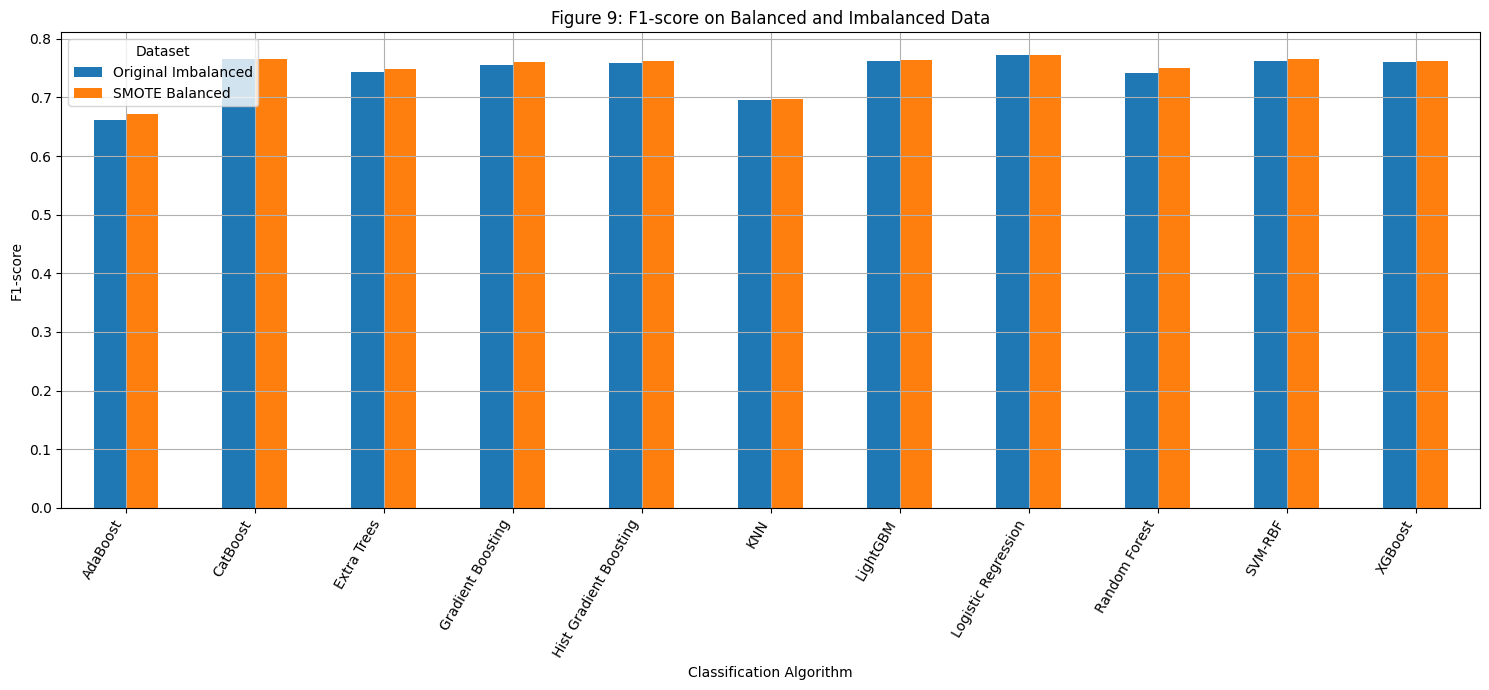

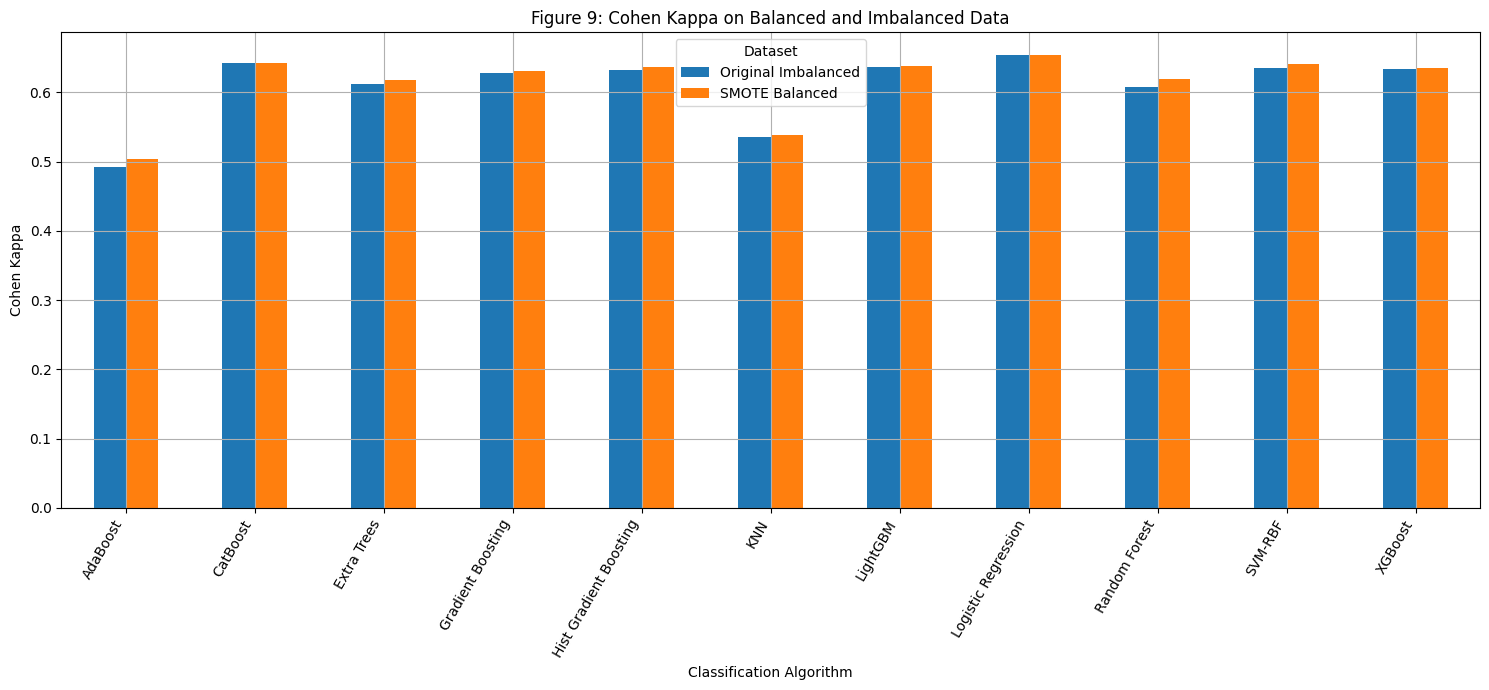

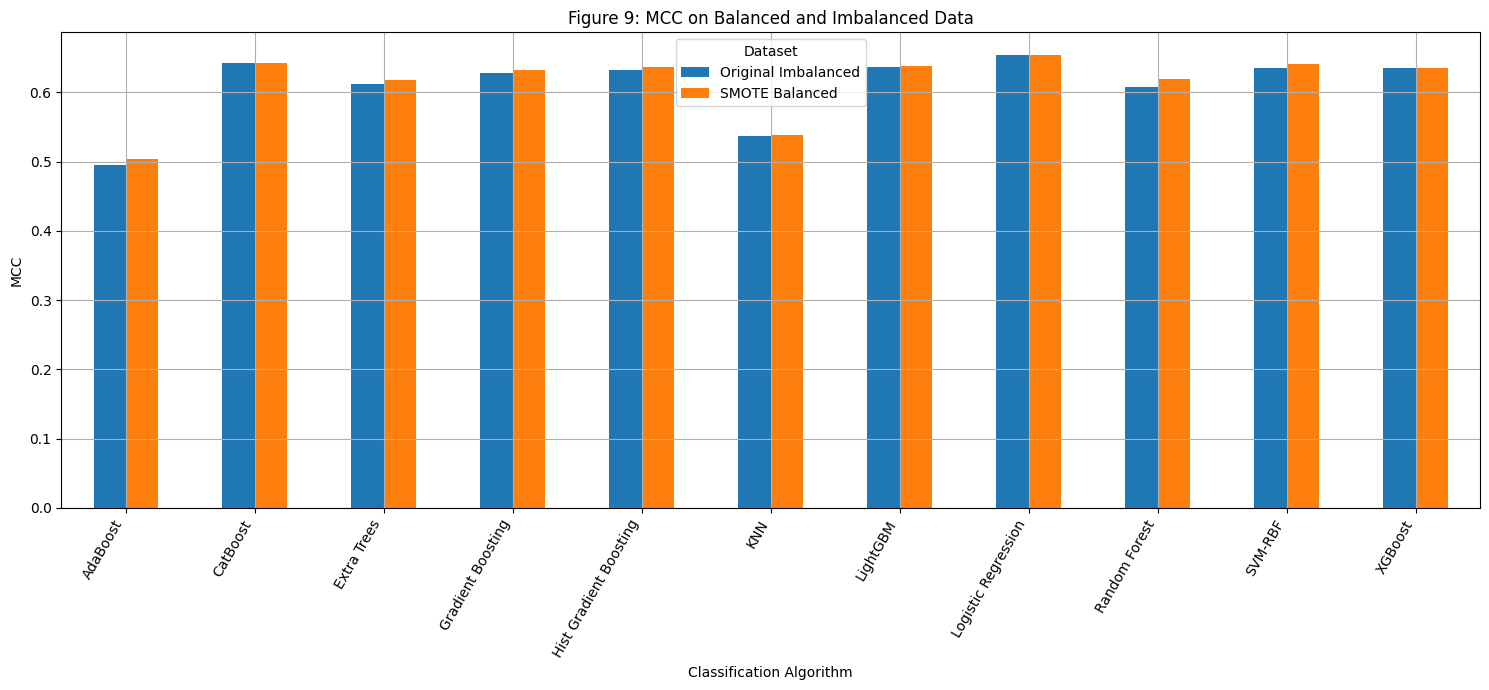

In [57]:
metrics_balanced = [
    "Accuracy",
    "Balanced Accuracy",
    "Sensitivity",
    "F1-score",
    "Cohen Kappa",
    "MCC"
]

for metric in metrics_balanced:

    pivot = comparison_all.pivot(
        index="Model",
        columns="Dataset",
        values=metric
    )

    ax = pivot.plot(
        kind="bar",
        figsize=(15, 7)
    )

    ax.set_ylabel(metric)
    ax.set_xlabel("Classification Algorithm")

    ax.set_title(
        f"Figure 9: {metric} on Balanced and Imbalanced Data"
    )

    plt.xticks(
        rotation=60,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

Select the best-performing algorithm automatically

In [58]:
results_ranked = results_df.copy()

results_ranked["Composite Score"] = (
    0.30 * results_ranked["ROC-AUC"] +
    0.20 * results_ranked["F1-score"] +
    0.15 * results_ranked["Balanced Accuracy"] +
    0.15 * results_ranked["Sensitivity"] +
    0.10 * results_ranked["Specificity"] +
    0.10 * results_ranked["MCC"]
)

results_ranked = results_ranked.sort_values(
    "Composite Score",
    ascending=False
).reset_index(drop=True)

display(
    results_ranked.round(4)
)

BEST_MODEL_NAME = results_ranked.loc[
    0,
    "Model"
]

BEST_MODEL = fitted_models[
    BEST_MODEL_NAME
]

print(
    "\nAutomatically selected best model:",
    BEST_MODEL_NAME
)

,Model,Accuracy,Precision,Sensitivity,Recall,Specificity,F1-score,ROC-AUC,Balanced Accuracy,Cohen Kappa,MCC,Log Loss,Composite Score
0,Logistic Regression,0.7775,0.7700,0.7752,0.7752,0.8861,0.7724,0.9162,0.7752,0.6538,0.6540,0.5021,0.8159
1,CatBoost,0.7698,0.7632,0.7684,0.7684,0.8818,0.7656,0.9145,0.7684,0.6418,0.6419,0.5051,0.8104
2,SVM-RBF,0.7688,0.7628,0.7679,0.7679,0.8817,0.7651,0.9112,0.7679,0.6407,0.6410,0.5172,0.8090
3,LightGBM,0.7672,0.7628,0.7662,0.7662,0.8808,0.7642,0.9106,0.7662,0.6382,0.6386,0.5290,0.8078
4,Hist Gradient Boosting,0.7662,0.7605,0.7655,0.7655,0.8799,0.7628,0.9110,0.7655,0.6364,0.6366,0.5233,0.8072
5,XGBoost,0.7655,0.7612,0.7642,0.7642,0.8798,0.7624,0.9122,0.7642,0.6354,0.6358,0.5166,0.8069
6,Gradient Boosting,0.7625,0.7577,0.7623,0.7623,0.8786,0.7596,0.9079,0.7623,0.6312,0.6316,0.5282,0.8040
7,Random Forest,0.7555,0.7490,0.7529,0.7529,0.8738,0.7509,0.9021,0.7529,0.6189,0.6190,0.5650,0.7960
8,Extra Trees,0.7550,0.7493,0.7493,0.7493,0.8729,0.7493,0.9057,0.7493,0.6171,0.6172,0.5962,0.7953
9,KNN,0.7010,0.6928,0.7027,0.7027,0.8479,0.6967,0.8556,0.7027,0.5376,0.5383,1.8411,0.7455



Automatically selected best model: Logistic Regression


Confusion matrix of the best model

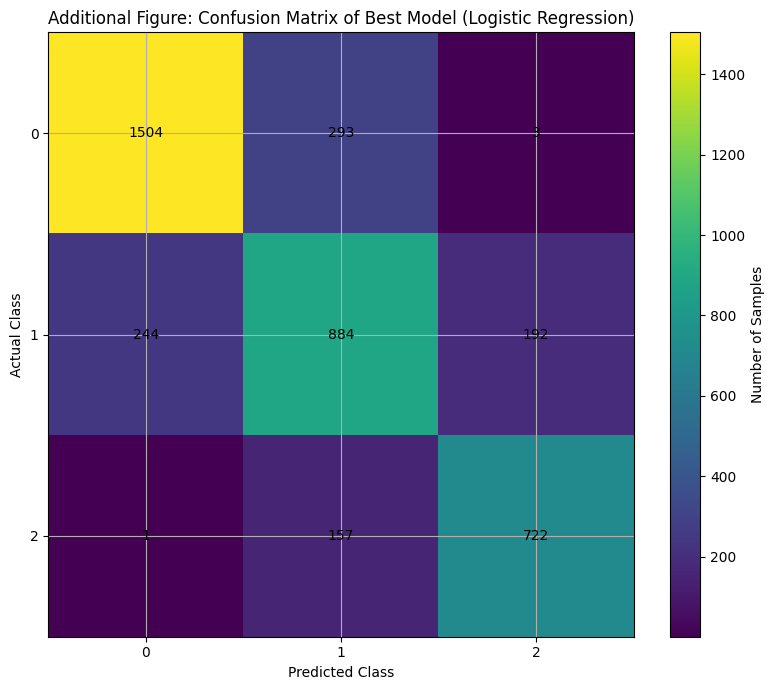

In [59]:
best_predictions = predictions[
    BEST_MODEL_NAME
]

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(8, 7))

plt.imshow(
    cm,
    aspect="auto"
)

plt.colorbar(
    label="Number of Samples"
)

plt.xticks(
    range(len(classes)),
    classes
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    f"Additional Figure: Confusion Matrix of Best Model ({BEST_MODEL_NAME})"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

Detailed classification report

In [60]:
print(
    f"Classification Report: {BEST_MODEL_NAME}"
)

print(
    classification_report(
        y_test,
        best_predictions,
        digits=4,
        zero_division=0
    )
)

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0     0.8599    0.8356    0.8476      1800
           1     0.6627    0.6697    0.6662      1320
           2     0.7874    0.8205    0.8036       880

    accuracy                         0.7775      4000
   macro avg     0.7700    0.7752    0.7724      4000
weighted avg     0.7789    0.7775    0.7780      4000



Per-class sensitivity and specificity

In [61]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

class_metrics = []

for i, class_label in enumerate(classes):

    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    sensitivity = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if (TN + FP) > 0
        else 0
    )

    precision = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else 0
    )

    npv = (
        TN / (TN + FN)
        if (TN + FN) > 0
        else 0
    )

    class_metrics.append({
        "Class": class_label,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "NPV": npv
    })

class_metrics_df = pd.DataFrame(
    class_metrics
)

display(
    class_metrics_df.round(4)
)

,Class,Sensitivity,Specificity,Precision,NPV
0,0,0.8356,0.8886,0.8599,0.8685
1,1,0.6697,0.8321,0.6627,0.8365
2,2,0.8205,0.9375,0.7874,0.9488


Best-model feature importance

In [62]:
if hasattr(BEST_MODEL, "feature_importances_"):

    component_importance = pd.Series(
        BEST_MODEL.feature_importances_,
        index=pca_columns
    )

else:

    component_importance = pd.Series(
        np.ones(len(pca_columns)),
        index=pca_columns
    )

original_importance = pd.Series(
    0.0,
    index=X_train_corr.columns
)

for component in pca_columns:

    component_index = pca_columns.index(
        component
    )

    original_importance += (
        component_importance[component] *
        np.abs(
            pca.components_[component_index]
        )
    )

original_importance = (
    original_importance /
    original_importance.sum()
)

original_importance = (
    original_importance
    .sort_values(ascending=False)
)

display(
    original_importance.to_frame(
        "Importance"
    ).round(4)
)

,Importance
distance_to_fault,0.0794
ps_time_diff,0.0774
longitude,0.0737
b_value,0.0722
azimuthal_gap,0.0698
latitude,0.0696
snr,0.0682
seismicity_rate,0.0638
inter_event_time,0.0621
groundwater_change,0.0578


Figure 10: Feature importance

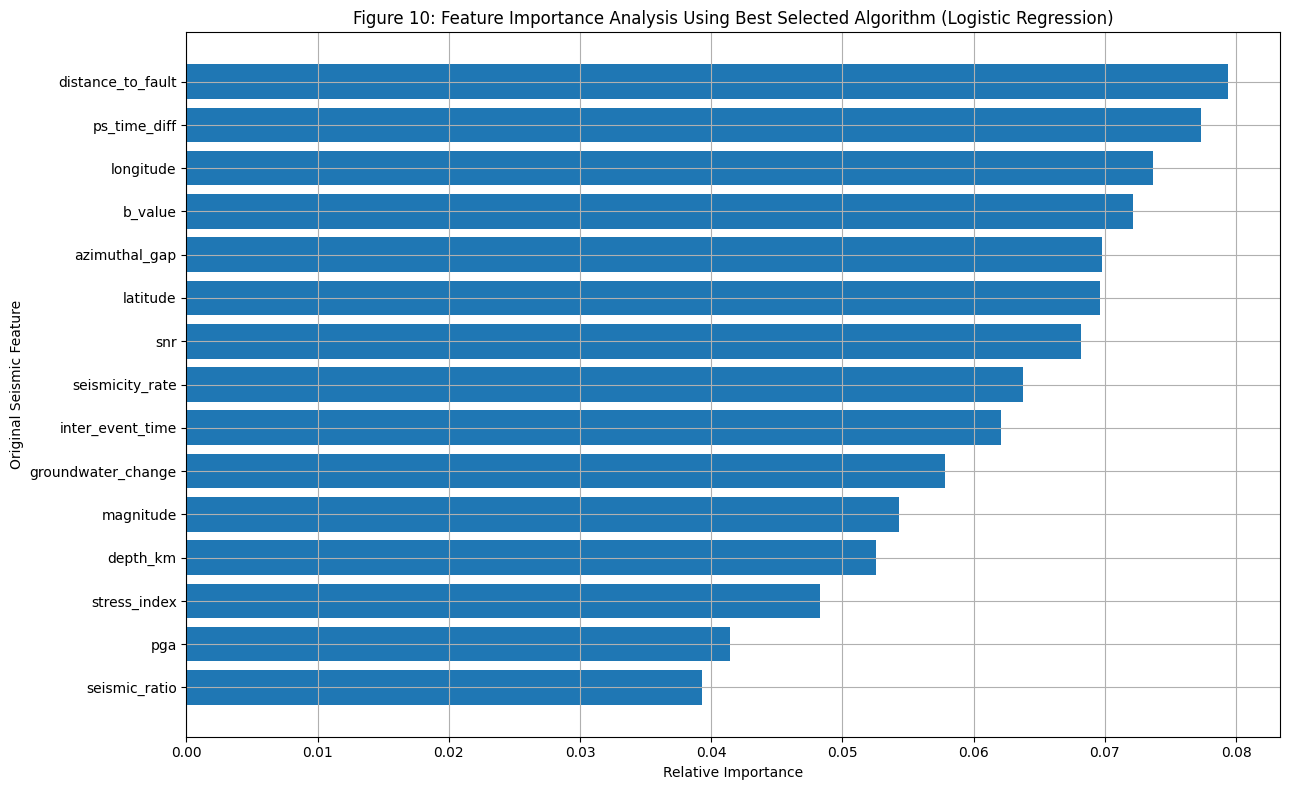

In [63]:
plt.figure(figsize=(13, 8))

importance_plot = original_importance.head(15)

plt.barh(
    importance_plot.index[::-1],
    importance_plot.values[::-1]
)

plt.xlabel(
    "Relative Importance"
)

plt.ylabel(
    "Original Seismic Feature"
)

plt.title(
    f"Figure 10: Feature Importance Analysis Using Best Selected Algorithm ({BEST_MODEL_NAME})"
)

plt.tight_layout()
plt.show()

SHAP analysis

In [64]:
try:

    shap_sample_size = min(
        1000,
        len(X_test_pca)
    )

    X_shap = X_test_pca.iloc[
        :shap_sample_size
    ]

    if BEST_MODEL_NAME in [
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Extra Trees",
        "Hist Gradient Boosting",
        "Gradient Boosting",
        "AdaBoost"
    ]:

        explainer = shap.TreeExplainer(
            BEST_MODEL
        )

        shap_values = explainer.shap_values(
            X_shap
        )

        if isinstance(
            shap_values,
            list
        ):

            mean_abs_shap = np.mean(
                np.abs(
                    np.stack(
                        shap_values
                    )
                ),
                axis=(0, 1)
            )

        else:

            mean_abs_shap = np.mean(
                np.abs(shap_values),
                axis=0
            )

        shap_component_importance = pd.Series(
            mean_abs_shap,
            index=X_shap.columns
        ).sort_values(
            ascending=False
        )

        print(
            "SHAP importance of PCA components:"
        )

        display(
            shap_component_importance.to_frame(
                "Mean |SHAP value|"
            )
        )

except Exception as e:

    print(
        "SHAP analysis could not be completed:",
        e
    )

SHAP VISUALIZATION

In [65]:
try:

    if "shap_values" in globals():

        if isinstance(
            shap_values,
            list
        ):

            shap.summary_plot(
                shap_values,
                X_shap,
                show=False
            )

        else:

            shap.summary_plot(
                shap_values,
                X_shap,
                show=False
            )

        plt.title(
            f"Additional Figure: SHAP Explainability Analysis of {BEST_MODEL_NAME}"
        )

        plt.tight_layout()
        plt.show()

except Exception as e:

    print(
        "SHAP visualization unavailable:",
        e
    )

Optional MLP deep-learning model

In [66]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(RANDOM_STATE)

X_nn_train = X_train_balanced.values
X_nn_test = X_test_pca.values

y_nn_train = to_categorical(
    y_train_balanced,
    num_classes=3
)

y_nn_test = to_categorical(
    y_test,
    num_classes=3
)

mlp_model = Sequential([
    Dense(
        128,
        activation="relu",
        input_shape=(X_nn_train.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.20),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        3,
        activation="softmax"
    )
])

mlp_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_nn_train,
    y_nn_train,
    validation_split=0.15,
    epochs=150,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6917 - loss: 0.6754 - val_accuracy: 0.8194 - val_loss: 0.4240
Epoch 2/150
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7536 - loss: 0.5486 - val_accuracy: 0.8451 - val_loss: 0.3677
Epoch 3/150
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7638 - loss: 0.5271 - val_accuracy: 0.8154 - val_loss: 0.3978
Epoch 4/150
287/287 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7680 - loss: 0.5203 - val_accuracy: 0.8309 - val_loss: 0.3815
Epoch 5/150
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7683 - loss: 0.5143 - val_accuracy: 0.8164 - val_loss: 0.4086
Epoch 6/150
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7728 - loss: 0.5098 - val_accuracy: 0.8228 - val_loss: 0.3919
Epoch 7/150
287/287 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7739 - loss: 0.5055 - val_accuracy: 0.8034 - val_loss: 0.4220
Epoch 8/150
287/287 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7729 - loss: 0.5077 - val_ac

Evaluate MLP

In [67]:
mlp_prob = mlp_model.predict(
    X_nn_test,
    verbose=0
)

mlp_pred = np.argmax(
    mlp_prob,
    axis=1
)

mlp_auc = roc_auc_score(
    y_test_bin,
    mlp_prob,
    multi_class="ovr",
    average="macro"
)

mlp_metrics = {
    "Model": "MLP",
    "Accuracy": accuracy_score(
        y_test,
        mlp_pred
    ),
    "Precision": precision_score(
        y_test,
        mlp_pred,
        average="macro",
        zero_division=0
    ),
    "Sensitivity": recall_score(
        y_test,
        mlp_pred,
        average="macro",
        zero_division=0
    ),
    "F1-score": f1_score(
        y_test,
        mlp_pred,
        average="macro",
        zero_division=0
    ),
    "ROC-AUC": mlp_auc,
    "Balanced Accuracy": balanced_accuracy_score(
        y_test,
        mlp_pred
    ),
    "Cohen Kappa": cohen_kappa_score(
        y_test,
        mlp_pred
    ),
    "MCC": matthews_corrcoef(
        y_test,
        mlp_pred
    )
}

print(
    pd.DataFrame([mlp_metrics]).round(4)
)

  Model  Accuracy  Precision  Sensitivity  F1-score  ROC-AUC  \
0   MLP     0.775     0.7701       0.7702    0.7701    0.916   

   Balanced Accuracy  Cohen Kappa     MCC  
0             0.7702       0.6489  0.6489  


Optional LSTM experiment

In [68]:
from tensorflow.keras.layers import LSTM

X_lstm_train = X_train_balanced.values.reshape(
    X_train_balanced.shape[0],
    X_train_balanced.shape[1],
    1
)

X_lstm_test = X_test_pca.values.reshape(
    X_test_pca.shape[0],
    X_test_pca.shape[1],
    1
)

lstm_model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_lstm_train.shape[1],
            1
        )
    ),

    Dropout(0.30),

    LSTM(
        32
    ),

    Dropout(0.20),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        3,
        activation="softmax"
    )
])

lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_history = lstm_model.fit(
    X_lstm_train,
    y_nn_train,
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=12,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.5967 - loss: 0.8359 - val_accuracy: 0.8840 - val_loss: 0.3870
Epoch 2/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.6726 - loss: 0.7076 - val_accuracy: 0.7988 - val_loss: 0.4613
Epoch 3/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6842 - loss: 0.6854 - val_accuracy: 0.7488 - val_loss: 0.5567
Epoch 4/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6910 - loss: 0.6671 - val_accuracy: 0.7071 - val_loss: 0.5809
Epoch 5/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.6967 - loss: 0.6565 - val_accuracy: 0.7120 - val_loss: 0.5732
Epoch 6/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6966 - loss: 0.6513 - val_accuracy: 0.6963 - val_loss: 0.6101
Epoch 7/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7000 - loss: 0.6472 - val_accuracy: 0.7281 - val_loss: 0.5522
Epoch 8/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7036 - loss: 0.6427 -

Evaluate LSTM

In [69]:
lstm_prob = lstm_model.predict(
    X_lstm_test,
    verbose=0
)

lstm_pred = np.argmax(
    lstm_prob,
    axis=1
)

lstm_auc = roc_auc_score(
    y_test_bin,
    lstm_prob,
    multi_class="ovr",
    average="macro"
)

lstm_metrics = {
    "Model": "LSTM",
    "Accuracy": accuracy_score(
        y_test,
        lstm_pred
    ),
    "Precision": precision_score(
        y_test,
        lstm_pred,
        average="macro",
        zero_division=0
    ),
    "Sensitivity": recall_score(
        y_test,
        lstm_pred,
        average="macro",
        zero_division=0
    ),
    "Specificity": multiclass_specificity(
        y_test,
        lstm_pred
    ),
    "F1-score": f1_score(
        y_test,
        lstm_pred,
        average="macro",
        zero_division=0
    ),
    "ROC-AUC": lstm_auc,
    "Balanced Accuracy": balanced_accuracy_score(
        y_test,
        lstm_pred
    ),
    "Cohen Kappa": cohen_kappa_score(
        y_test,
        lstm_pred
    ),
    "MCC": matthews_corrcoef(
        y_test,
        lstm_pred
    )
}

lstm_df = pd.DataFrame(
    [lstm_metrics]
)

display(
    lstm_df.round(4)
)

,Model,Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC,Balanced Accuracy,Cohen Kappa,MCC
0,LSTM,0.6212,0.6199,0.6457,0.8159,0.6178,0.8213,0.6457,0.4317,0.4404


Combine classical ML + deep-learning results

In [70]:
final_results = results_ranked.copy()

final_results = pd.concat(
    [
        final_results,
        pd.DataFrame([mlp_metrics]),
        lstm_df
    ],
    ignore_index=True
)

final_results["Composite Score"] = final_results[
    [
        "ROC-AUC",
        "F1-score",
        "Balanced Accuracy",
        "Sensitivity",
        "MCC"
    ]
].mean(axis=1)

final_results = final_results.sort_values(
    "Composite Score",
    ascending=False
).reset_index(drop=True)

display(
    final_results.round(4)
)

print(
    "Overall best-performing algorithm:",
    final_results.loc[0, "Model"]
)

,Model,Accuracy,Precision,Sensitivity,Recall,Specificity,F1-score,ROC-AUC,Balanced Accuracy,Cohen Kappa,MCC,Log Loss,Composite Score
0,Logistic Regression,0.7775,0.7700,0.7752,0.7752,0.8861,0.7724,0.9162,0.7752,0.6538,0.6540,0.5021,0.7786
1,MLP,0.7750,0.7701,0.7702,NaN,NaN,0.7701,0.9160,0.7702,0.6489,0.6489,NaN,0.7751
2,CatBoost,0.7698,0.7632,0.7684,0.7684,0.8818,0.7656,0.9145,0.7684,0.6418,0.6419,0.5051,0.7717
3,SVM-RBF,0.7688,0.7628,0.7679,0.7679,0.8817,0.7651,0.9112,0.7679,0.6407,0.6410,0.5172,0.7706
4,LightGBM,0.7672,0.7628,0.7662,0.7662,0.8808,0.7642,0.9106,0.7662,0.6382,0.6386,0.5290,0.7691
5,Hist Gradient Boosting,0.7662,0.7605,0.7655,0.7655,0.8799,0.7628,0.9110,0.7655,0.6364,0.6366,0.5233,0.7683
6,XGBoost,0.7655,0.7612,0.7642,0.7642,0.8798,0.7624,0.9122,0.7642,0.6354,0.6358,0.5166,0.7677
7,Gradient Boosting,0.7625,0.7577,0.7623,0.7623,0.8786,0.7596,0.9079,0.7623,0.6312,0.6316,0.5282,0.7647
8,Random Forest,0.7555,0.7490,0.7529,0.7529,0.8738,0.7509,0.9021,0.7529,0.6189,0.6190,0.5650,0.7556
9,Extra Trees,0.7550,0.7493,0.7493,0.7493,0.8729,0.7493,0.9057,0.7493,0.6171,0.6172,0.5962,0.7541


Overall best-performing algorithm: Logistic Regression


Final ROC comparison including MLP and LSTM

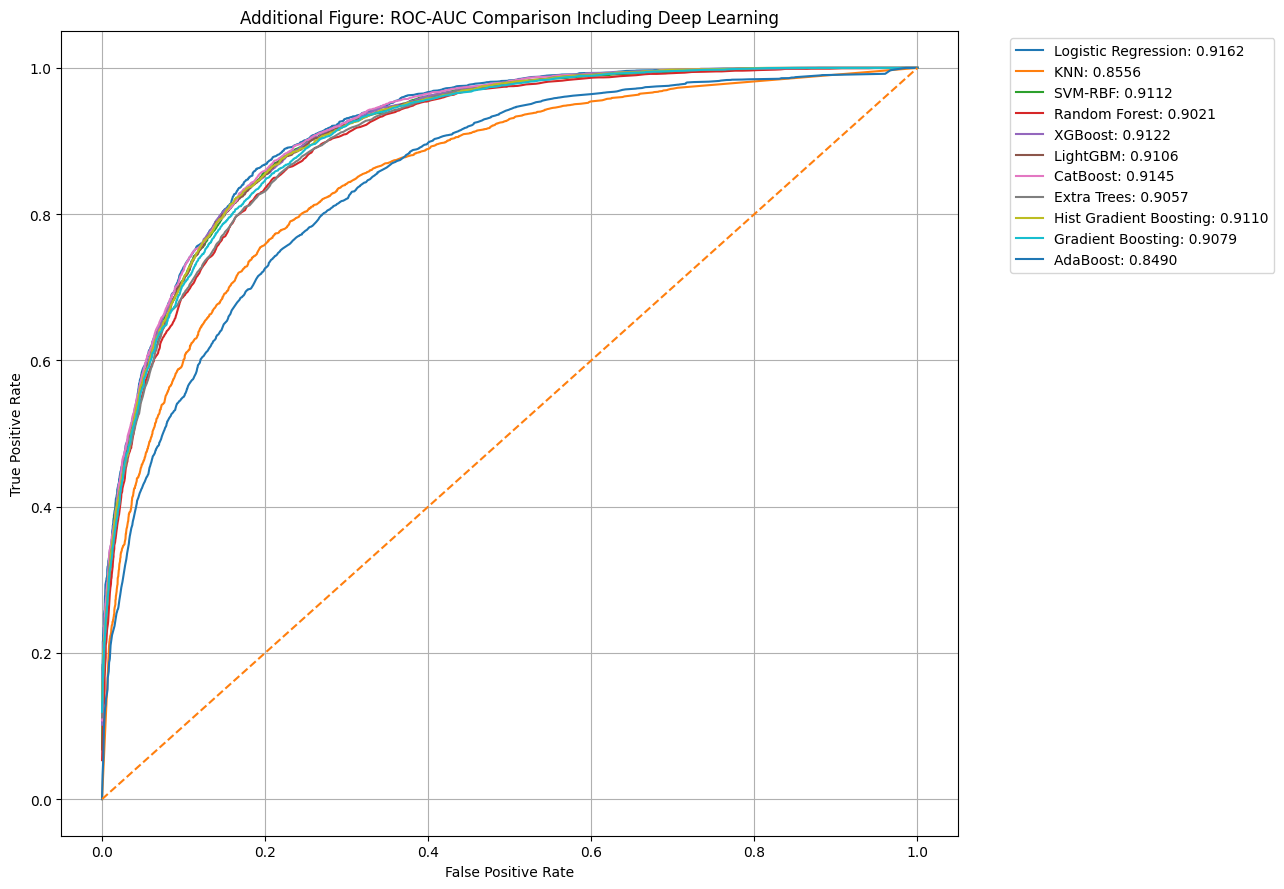

In [71]:
plt.figure(figsize=(13, 9))

for name in models.keys():

    y_prob = probabilities[name]

    fpr = {}
    tpr = {}

    for i in range(3):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

    all_fpr = np.unique(
        np.concatenate(
            [
                fpr[i]
                for i in range(3)
            ]
        )
    )

    mean_tpr = np.zeros_like(
        all_fpr
    )

    for i in range(3):

        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= 3

    score = roc_auc_score(
        y_test_bin,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        label=f"{name}: {score:.4f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Additional Figure: ROC-AUC Comparison Including Deep Learning"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Statistical agreement and error analysis

In [72]:
best_pred = predictions[
    BEST_MODEL_NAME
]

print("Cohen's Kappa:")
print(
    cohen_kappa_score(
        y_test,
        best_pred
    )
)

print("\nMatthews Correlation Coefficient:")
print(
    matthews_corrcoef(
        y_test,
        best_pred
    )
)

print("\nBalanced Accuracy:")
print(
    balanced_accuracy_score(
        y_test,
        best_pred
    )
)

print("\nMacro Precision:")
print(
    precision_score(
        y_test,
        best_pred,
        average="macro",
        zero_division=0
    )
)

print("\nMacro Sensitivity:")
print(
    recall_score(
        y_test,
        best_pred,
        average="macro",
        zero_division=0
    )
)

print("\nMacro F1:")
print(
    f1_score(
        y_test,
        best_pred,
        average="macro",
        zero_division=0
    )
)

Cohen's Kappa:
0.6538298476462374

Matthews Correlation Coefficient:
0.6539669335661457

Balanced Accuracy:
0.7752356902356903

Macro Precision:
0.7699795581507901

Macro Sensitivity:
0.7752356902356903

Macro F1:
0.7724294884742093


Save all research results

In [73]:
os.makedirs(
    "/content/research_outputs",
    exist_ok=True
)

results_ranked.to_csv(
    "/content/research_outputs/classification_results.csv",
    index=False
)

comparison_all.to_csv(
    "/content/research_outputs/balanced_vs_imbalanced_results.csv",
    index=False
)

correlation_analysis.to_csv(
    "/content/research_outputs/correlation_analysis.csv",
    index=False
)

class_metrics_df.to_csv(
    "/content/research_outputs/per_class_metrics.csv",
    index=False
)

original_importance.to_csv(
    "/content/research_outputs/feature_importance.csv"
)

print(
    "Research results saved to /content/research_outputs/"
)

Research results saved to /content/research_outputs/


Create a final research summary

In [74]:
best_row = final_results.iloc[0]

print("=" * 70)
print("FINAL RESEARCH MODEL SUMMARY")
print("=" * 70)

print(
    f"Best Model: {best_row['Model']}"
)

print(
    f"Accuracy: {best_row['Accuracy']:.4f}"
)

print(
    f"Precision: {best_row['Precision']:.4f}"
)

print(
    f"Sensitivity: {best_row['Sensitivity']:.4f}"
)

if "Specificity" in best_row:
    print(
        f"Specificity: {best_row['Specificity']:.4f}"
    )

print(
    f"F1-score: {best_row['F1-score']:.4f}"
)

print(
    f"ROC-AUC: {best_row['ROC-AUC']:.4f}"
)

print(
    f"Balanced Accuracy: {best_row['Balanced Accuracy']:.4f}"
)

print(
    f"Cohen Kappa: {best_row['Cohen Kappa']:.4f}"
)

print(
    f"MCC: {best_row['MCC']:.4f}"
)

print("=" * 70)

FINAL RESEARCH MODEL SUMMARY
Best Model: Logistic Regression
Accuracy: 0.7775
Precision: 0.7700
Sensitivity: 0.7752
Specificity: 0.8861
F1-score: 0.7724
ROC-AUC: 0.9162
Balanced Accuracy: 0.7752
Cohen Kappa: 0.6538
MCC: 0.6540
